# LeJEPA for Label-Efficient, Explainable Defect Detection in Injection Moulding

**Clean, fully documented pipeline** (version 06). This notebook merges the
end-to-end pipeline of `04_architecture_updated.ipynb` with the step-by-step
Active Learning walk-through developed in `05_debug_architecture_updated.ipynb`,
and adds an explanation block after every phase.

**The architecture is unchanged.** What changed is the *code* (one configuration
cell, one reusable pre-training function shared by STEP 3 and STEP 6, self-tests,
a deterministic option for the acquisition score, extra diagnostics and
baselines) and the *documentation* (every phase is followed by a plain-language
explanation of what each cell does, what goes in, what comes out, and why it is
there, plus the questions people are likely to ask).

Everything runs on CPU. The whole notebook, including five pre-training seeds,
takes a few minutes.

### How to read this notebook

| If you want to ... | Go to |
| --- | --- |
| understand the idea in one page before any code | **The big idea** (next section) |
| see the whole design at a glance | **Architecture** |
| change a knob (budget, latent size, seeds, paths) | **STEP 0** — every parameter lives there |
| follow the pipeline phase by phase | STEP 1 → STEP 8, each followed by an *Explanation* block |
| debug something that looks wrong | **Diagnostic checklist** (after STEP 8) |
| try experiments | **Experiments to try** |
| look up a term | **Glossary** |
| write or present the paper | **Research notes N1–N7** and **The aim of this architecture** at the end |

**Conventions used throughout**

- Code cells are named `STEP n` and do one thing each. A markdown block titled
  *Explanation* follows every phase and uses the same four questions for each
  cell: **what it does, input, output, why it exists**.
- `x` is one cycle (26 standardised sensors), `mask` is a 0/1 vector (1 = sensor
  visible, 0 = hidden), `z_*` is an 8-number latent vector.
- Labels `y` (1 = defect) are read **only** in STEP 4 for the 300 queried cycles and
  afterwards for evaluation. Pre-training never sees them.
- Printed numbers depend on the seed. Data facts (26 sensors, 19 with a >0.9 twin,
  9 blocks, effective rank ~4) do not.

## The big idea, in one page

### The problem

You have **5232 moulding cycles**, each described by **26 sensor readings**. Only
**60 cycles (1.15 %)** are known defects. Labelling is expensive: a person must
inspect a part to say pass or fail. So there are two jobs:

1. Learn something useful from the **unlabelled** data.
2. Spend a small labelling budget on the **most informative** cycles.

LeJEPA does job 1. The latent-error score does job 2. A Random Forest on the raw
sensors plus SHAP turns the result into something an operator can act on, and a
blinded domain expert checks whether those explanations are real.

### "Self-supervised" = invent a task the data can grade itself

No labels needed. We hide some sensors and ask the model to work out what the
hidden ones imply. To do that well, the model has to learn how the machine's
variables hang together, in effect its process physics.

### The JEPA twist: predict *representations*, not raw numbers

- An **autoencoder** hides sensors and predicts the **missing sensor values**.
- A **JEPA** hides sensors and predicts the **missing representation**.

Sensor readings contain noise that nobody can predict. Forcing the model to output
exact numbers makes it spend capacity memorising jitter. Letting it predict a
compressed summary lets it learn "this is a hot, slow, high-pressure cycle" and
ignore the unguessable part. In this notebook the idea is four lines (STEP 3):

```python
z_context = enc(xb, mask)             # embedding of the VISIBLE sensors
z_target  = encode_full(enc, xb)      # embedding of the WHOLE cycle
z_pred    = pred(z_context)           # our guess at z_target
loss, inv, iso = lejepa_loss(z_context, z_target, z_pred, lam=lam)
```

Each `z` is just **8 numbers**. We never try to reproduce the 26 sensor values.

The name decodes as: **Joint-Embedding** (both views go through the *same*
encoder), **Predictive** (one embedding predicts the other), **Architecture** (a
design pattern, not one fixed network).

### The catch: collapse

Suppose the encoder maps *every* cycle to the same vector. Then `z_target` is
always identical, the predictor guesses it perfectly, and the loss goes to zero.
The model has learned nothing but has "won". This is **representation collapse**,
the central difficulty of the JEPA family. Two ways to prevent it:

1. **Asymmetry tricks**: stop-gradient or a slowly updated "teacher" copy of the
   network (BYOL, DINO, I-JEPA).
2. **An explicit regulariser** on the *distribution* of embeddings (VICReg, LeJEPA).

LeJEPA takes route 2 with a specific target: **the embeddings should be
distributed like an isotropic Gaussian**. The term enforcing this is **SIGReg**
(Sketched Isotropic Gaussian Regularization). The pay-off of doing route 2
properly is that route-1 machinery is unnecessary: the training loop has no
`.detach()` and no teacher network.

### Why *isotropic Gaussian* specifically?

- **Isotropic**: the same spread in every direction, so no direction is dead.
- **Gaussian**: the most spread-out distribution for a given variance, so it packs
  in the most information.
- **The practical pay-off**: STEP 4 ranks cycles by a plain Euclidean distance
  `‖z_target − z_pred‖`. That number is only trustworthy if one unit of distance
  means the same thing in every direction. Isotropy is exactly that guarantee. The
  regulariser and the active-learning score are therefore *coupled*, not two
  modules bolted together.

### The whole objective

```
loss  =  invariance  +  λ · SIGReg
         "predict the    "and keep the embedding
          target"         distribution healthy"
```

`λ` (`LAMBDA_SIGREG = 1.0`) is the single trade-off knob.

### Concept → code map

| Idea | Where it lives |
| --- | --- |
| Embedding (representation) | `LeJEPAEncoder` (STEP 2) |
| The two views | `mask` vs `encode_full` (STEP 3) |
| Predict one embedding from the other | `LeJEPAPredictor` (STEP 2) |
| Invariance / prediction term | `invariance` inside `lejepa_loss` |
| Anti-collapse regulariser | `sigreg` (STEP 2) |
| Collapse *measurement* | `effective_rank` (STEP 2) |
| Using the model to pick labels | `latent_uncertainty` / `acquisition_score` (STEP 2, used in STEP 4 and 6) |

> **A note on fidelity.** `sigreg` implements the *idea* of a sketched
> isotropic-Gaussian test in a compact, readable way. The reference
> implementation's exact statistic may differ in detail. If you cite LeJEPA,
> describe what this code does.

## Architecture

*The full pipeline as implemented below. Design decisions that differ from the
original draft are tabulated at the end, with the reason for each.*

```
    UNLABELED SINGLE MANUFACTURING CYCLE (snapshot: 26 standardised sensors)
                                     │
              26 sensors clustered by |correlation| into 9 blocks
              (19/26 sensors have a >0.9 twin, so masking sensors
               independently leaks the answer 64 % of the time)
                                     │
                  ┌──────────────────┴──────────────────┐
                  │                                     │
              CONTEXT VIEW                         TARGET VIEW
      (whole correlated BLOCKS hidden)        (full cycle, nothing hidden)
                  │                                     │
          [ x * mask , mask ]                     [ x , ones ]
              52 inputs                             52 inputs
                  │                                     │
       mask is an EXPLICIT channel:          the target is the FULL cycle,
       after StandardScaler a hidden         which is exactly what the
       sensor (0.0) is otherwise             active-learning step scores
       identical to an average one           against (no train/eval mismatch)
                  ↓                                     ↓
        ┌─────────────────────────┐         ┌─────────────────────────┐
        │   Shared MLP Encoder    │  same   │   Shared MLP Encoder    │
        │   52 → 64 → 32 → 8      │ weights │   52 → 64 → 32 → 8      │
        │   LayerNorm + GELU      │         │   LayerNorm + GELU      │
        └────────────┬────────────┘         └────────────┬────────────┘
                     ↓                                   ↓
              z_context (8-d)                      z_target (8-d)
                     ↓                                   │
        ┌─────────────────────────┐                      │
        │    LeJEPA Predictor     │                      │
        │       8 → 32 → 8        │                      │
        └────────────┬────────────┘                      │
                     ↓                                   │
                z_pred (8-d)                             │
                     └─────────────────┬─────────────────┘
                                       ↓
                      Loss  =  invariance  +  λ · SIGReg       (λ = 1.0)

      ┌────────────────────────────────────────────────────────────────────┐
      │  invariance :  MSE( z_target , z_pred )                            │
      │  SIGReg     :  ½ [ sig(z_context) + sig(z_target) ]                │
      │     sig(·) = Sketched Isotropic Gaussian Regularization            │
      │              1. sketch the batch onto 64 random unit directions    │
      │              2. along each direction, compare the empirical        │
      │                 characteristic function against that of N(0,1)     │
      │                 at 17 points in t ∈ [-3, 3]                        │
      │     The reference is N(0,1) ITSELF, so one term penalises          │
      │     collapse, anisotropy AND non-Gaussian tails.                   │
      │  Both branches stay LIVE: no stop-gradient and no EMA teacher.     │
      └────────────────────────────────────────────────────────────────────┘
                                       │
          AdamW + cosine LR · 15 % held-out split · early stopping on the
          held-out objective · best checkpoint restored (not the last one)
          diagnostics: loss decomposition + latent EFFECTIVE RANK per epoch
                                       │
    ═══════════════════════════════════│════════════════════════════════════
    DOWNSTREAM TASKS  (labels enter here)
                                       ↓
      ┌────────────────────────────────────────────────────────────────────┐
      │                    ACTIVE LEARNING  (single-shot)                  │
      │  frozen encoder + frozen predictor + X (all cycles)                │
      │        ──>  score per cycle = ‖ z_target − z_pred ‖₂               │
      │             averaged over 10 independent block-mask draws          │
      │             (or, deterministically, over all 510 admissible masks) │
      │        ──>  query the top 300 most uncertain cycles                │
      │                ┌─────────────────────┴─────────────────────┐       │
      │       RandomForest on the                             RANDOM-300   │
      │     queried 300 RAW cycles                             BASELINE    │
      │      (balanced_subsample)                             (10 draws)   │
      │                └─────────────────────┬─────────────────────┘       │
      │                       compare on the holdout by AUPRC              │
      │      (at a 1.15 % defect rate accuracy and F1 are uninformative)   │
      └────────────────────────────────────┬───────────────────────────────┘
                                           ↓
      ┌────────────────────────────────────────────────────────────────────┐
      │                      EXPLAINABILITY (SHAP)                         │
      │  TreeExplainer on the RAW physical sensors, never on the latent,   │
      │  so attributions stay in engineering units an operator can act on. │
      │  SHAP values → operating window & global importance reports        │
      └────────────────────────────────────┬───────────────────────────────┘
                                           ↓
      ┌────────────────────────────────────────────────────────────────────┐
      │                    HUMAN VALIDATION (STEP 7)                       │
      │  A domain expert rates each explanation, blinded to condition:     │
      │    A   LeJEPA-queried classifier      (the proposed method)        │
      │    B   random-queried classifier      (budget-matched control)     │
      │    C   A magnitudes, permuted names   (falsification control)      │
      │  A vs C is the decisive test.                                      │
      └────────────────────────────────────────────────────────────────────┘
```

### Shapes

| Stage | Object | Shape |
| --- | --- | --- |
| Input | one cycle | 26 sensors |
| Encoder input | `[x * mask, mask]` | 52 values |
| Encoder output | `z_context`, `z_target` | 8 |
| Predictor output | `z_pred` | 8 |
| Acquisition score | one number per cycle | 5232 |
| Query set | queried cycles | 300 × 26 |
| SHAP | attributions | 300 × 26 |

### Five things the picture is saying

1. **One encoder, two views.** The same weights process the masked cycle and the
   full cycle. The mask travels with the data as its own channel, so the input is
   52 wide and not 26.
2. **The target is the full cycle**, not the complementary mask. It is the same
   quantity the active-learning score is computed against.
3. **Both branches stay live.** No stop-gradient, no teacher network; SIGReg alone
   keeps the latent from collapsing.
4. **Learn in latent, decide in physical units.** The classifier is fitted on raw
   sensors, never on embeddings, so SHAP lands on quantities an operator can act on.
5. **The loop ends with a person.** A blinded domain expert judges each explanation
   against a permuted-name control, so the human-centred claim is measured rather
   than asserted.

### Two humans, two jobs

| | Where | Role |
| --- | --- | --- |
| HITL-1 | STEP 4 | **Oracle**: supplies pass/fail for the 300 queried cycles (simulated here by reading the dataset label) |
| HITL-2 | STEP 7 | **Validator**: judges whether the explanation is credible and actionable |

### Design decisions (and what they replaced)

| Original draft | Current implementation | Why |
| --- | --- | --- |
| View 2 = complementary masked sensors | View 2 = the **full cycle** | Training predicts the same quantity active learning scores against |
| `x * mask` only | `[x * mask, mask]` concatenated | After standardisation a hidden sensor and an average sensor are the identical vector |
| Independent per-sensor masking | Whole **correlated blocks** masked | Removes the 64 % correlated-twin leak that made the pretext task trivial |
| `latent_dim = 32`, wider than the 26-d input | `latent_dim = 8` | The sensor block has an effective rank of only ~4 |
| `BatchNorm1d` | `LayerNorm` | The two views have different sparsity, so batch statistics pool two distributions |
| `z2.detach()` stop-gradient | No stop-gradient, no EMA teacher | LeJEPA's stated advantage is that proper isotropy removes this machinery |
| Variance hinge on the **detached** target | SIGReg on **both live** branches | The old term had `requires_grad=False` and contributed exactly zero gradient |
| 500 epochs, fixed | 150 epochs, cosine LR, early stopping on a held-out split | Distinguishes convergence from overfitting |
| Uncertainty from 1 mask draw | Averaged over 10 draws (exact expectation available) | A single draw is a one-sample estimate of a noisy variable |
| No baseline; accuracy / F1 reported | Random-300 baseline (and a PCA baseline); AUPRC reported | Enrichment cannot be attributed to the score without a baseline |
| Explanations asserted to be actionable | **Blinded expert evaluation** with a permuted-name control | An unvalidated explanation is a claim, not a result |

### What is new in version 06 relative to 04 (code only, same architecture)

| Change | Where | Why |
| --- | --- | --- |
| One configuration cell | STEP 0 | Every knob in one place; no magic numbers in later cells |
| `pretrain_lejepa()` used by STEP 3 **and** STEP 6 | STEP 3 | The paper's multi-seed numbers now use exactly the same protocol as the main run |
| Private random generators for masks | STEP 2, 3 | Validation and scoring no longer disturb the global RNG |
| Self-tests of every building block | STEP 2b | Self-supervised training fails quietly; test the pieces first |
| `acquisition_score(mode='mc'|'exact')` | STEP 2 | The exact expectation over all 510 masks is deterministic and costs 0.5 s |
| Active learning split into 4.0–4.6 with diagnostics | STEP 4 | Enrichment curve, event counting, fixed test set, mask-noise check, trivial baselines |
| PCA baseline in the multi-seed sweep | STEP 6 | Answers "would a trivial outlier score do the same?" with error bars |
| Forests use all cores; forest seed follows the run seed | STEP 4, 6 | Faster, and classifier randomness is inside the error bars |
| Guard against overwriting a filled expert form | STEP 7a | Never destroy collected responses |
| Run summary table | STEP 8 | Every number the paper quotes, in one place |

## STEP 0 — Setup and configuration

In [2]:
# =============================================================================
# STEP 0: Imports, reproducibility, and ONE place for every knob in the pipeline
# =============================================================================
# Everything that can be tuned lives in this cell. Later cells only *use* these
# names, so if you want to change the budget, the latent width, the number of
# seeds, or the file paths, you change them here and re-run from the top.
import os
import time
import textwrap
import warnings

warnings.filterwarnings('ignore', message='IProgress not found')                 # tqdm/ipywidgets cosmetics
warnings.filterwarnings('ignore', category=FutureWarning, message='The NumPy global RNG')  # shap notice

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, wilcoxon

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
)

T_START = time.time()                     # wall-clock for the run summary at the end

# ---------------- reproducibility & CPU budget --------------------------------
# CPU-only by design: pre-training costs ~20 s, so every number in the paper can
# be averaged over several seeds (STEP 6) instead of being quoted from one run.
SEED = 42
N_THREADS = 8
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_num_threads(N_THREADS)

# ---------------- data (STEP 1) ----------------------------------------------
DATA_PATH = '../data/labeled_data_preprocessed.csv'
METADATA_COLUMNS = ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
                    'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'Reason', 'PassOrFail']
LABEL_COLUMN = 'PassOrFail'               # 1 = defect, 0 = pass
REASON_COLUMN = 'Reason'                  # free-text defect type; used only for reporting
DEAD_SENSOR_MODAL_SHARE = 0.95            # a sensor whose single most common value covers
                                          # more than this share of rows is "dead"
DROP_DEAD_SENSORS = False                 # False = keep all 26 sensors (the numbers quoted in
                                          # the abstract); True = drop them (N4 gap 15)

# ---------------- correlated sensor blocks (STEP 1) --------------------------
BLOCK_DISTANCE_CUT = 0.3                  # cluster sensors with 1-|corr| < 0.3, i.e. |corr| > 0.7

# ---------------- model (STEP 2) ---------------------------------------------
LATENT_DIM = 8                            # the sensor block has an effective rank of ~4
ENCODER_HIDDEN = (64, 32)                 # 52 -> 64 -> 32 -> LATENT_DIM
PREDICTOR_HIDDEN = 32                     # LATENT_DIM -> 32 -> LATENT_DIM
KEEP_PROB = 0.5                           # probability that a block stays VISIBLE in a mask
SIGREG_N_PROJ = 64                        # random directions for the sketched Gaussian test
SIGREG_T_MAX, SIGREG_N_T = 3.0, 17        # probe points of the characteristic function

# ---------------- pre-training (STEP 3) --------------------------------------
EPOCHS = 150
BATCH_SIZE = 256
LEARNING_RATE = 3e-3
WEIGHT_DECAY = 1e-4
LAMBDA_SIGREG = 1.0                       # LeJEPA's single trade-off knob
VAL_FRAC = 0.15                           # label-free held-out cycles for early stopping
PATIENCE = 25                             # epochs without val improvement before stopping
LOG_EVERY = 25

# ---------------- active learning (STEP 4) -----------------------------------
LABELING_BUDGET = 300                     # simulated human-in-the-loop budget
N_MASK_DRAWS = 50                         # mask draws averaged per cycle when scoring
SCORING_MODE = 'mc'                       # 'mc'    = mean over N_MASK_DRAWS random masks
                                          #           (the architecture as stated in the paper)
                                          # 'exact' = mean over ALL admissible block masks
                                          #           (deterministic; compared in STEP 4.6b)
N_RANDOM_BASELINE_DRAWS = 10
RF_N_ESTIMATORS = 300
RF_N_JOBS = -1                            # use every core for the forests

# ---------------- multi-seed evaluation (STEP 6) -----------------------------
SEEDS = [0, 1, 2, 3, 4]

# ---------------- expert study (STEP 7) --------------------------------------
EXPERT_DIR = 'expert_study'
N_EXPERT_ITEMS = 18
EXPERT_PACKET_SEED = 20260908             # fixed: the packet must be reproducible

# ---------------- plotting ----------------------------------------------------
BLUE, ORANGE, GRAY, GREEN, RED = '#2a78d6', '#eb6834', '#898781', '#1baf7a', '#e34948'

print(f"torch {torch.__version__} | threads={torch.get_num_threads()} | seed={SEED} "
      f"| scoring={SCORING_MODE} | budget={LABELING_BUDGET} | seeds={SEEDS}")

torch 2.14.0+cpu | threads=8 | seed=42 | scoring=mc | budget=300 | seeds=[0, 1, 2, 3, 4]


### Explanation: STEP 0

| | |
| --- | --- |
| **What it does** | Imports the libraries, fixes every random seed, limits PyTorch to 8 CPU threads, and defines **every tunable parameter** of the pipeline as a named constant. |
| **Input** | Nothing. |
| **Output** | The constants used by all later cells (`SEED`, `LATENT_DIM`, `LABELING_BUDGET`, `SEEDS`, file paths, ...). |
| **Why it exists** | So that changing the study (a different budget, more seeds, another dataset) means editing one cell, and so that nobody has to hunt for a magic number inside a training loop. |

**Reproducibility.** `torch.manual_seed`, `np.random.seed` and
`use_deterministic_algorithms` make a run repeatable on the same machine. Later
cells that need randomness (masks, random baselines, the expert packet) create
their **own** seeded generators so that re-running one cell does not silently
change the results of another.

**Two switches you may want to flip**

- `SCORING_MODE`: `'mc'` averages the latent error over 10 random mask draws, which
  is the architecture as described in the paper; `'exact'` averages over all 510
  admissible block masks, which is deterministic. STEP 4.6b shows how much the
  two differ.
- `DROP_DEAD_SENSORS`: two sensors are effectively constant (STEP 1 reports them).
  `False` keeps the 26-sensor setting the abstract quotes; `True` drops them
  before scaling (recommended for the full paper, see research note N4 gap 15).

**Question you may get:** *"Why CPU only?"* The encoder has under 6000 parameters
and pre-training takes about 20 s. A GPU would change nothing except the ability
to claim the method retrains on an edge device on the shop floor.

## STEP 1 — Data preparation and sensor structure

Load the cycles, standardise the 26 sensors, and **measure** the data before
designing the model: how many independent degrees of freedom the sensors carry,
and which sensors move together.

In [3]:
# =============================================================================
# STEP 1: Data preparation and sensor structure
# =============================================================================
# 1. Load the dataset --------------------------------------------------------
df = pd.read_csv(DATA_PATH)

# 2. Separate sensors (X) from the label (y) and the metadata -----------------
X = df.drop(columns=METADATA_COLUMNS)
y = df[LABEL_COLUMN].values.astype(int)
reason = df[REASON_COLUMN].fillna('(pass)').values     # for reporting only, never for modelling

# 3. Data-quality report: near-constant ("dead") sensors -----------------------
#    A sensor whose single value covers >95% of rows carries no information, but
#    StandardScaler turns its few odd rows into extreme outliers (z up to +72).
modal_share = X.apply(lambda col: col.value_counts(normalize=True).iloc[0])
dead_sensors = modal_share[modal_share > DEAD_SENSOR_MODAL_SHARE].index.tolist()
if DROP_DEAD_SENSORS and dead_sensors:
    X = X.drop(columns=dead_sensors)
feature_names = X.columns.tolist()

# 4. Standardise every sensor (mean 0, sd 1) -----------------------------------
#    Mandatory: the whole LeJEPA objective is built on distances and variances.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Tensors for PyTorch --------------------------------------------------------
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
input_dim = X_tensor.shape[1]
n_cycles, n_defects = len(y), int(y.sum())
base_rate = y.mean()

print(f"Dataset: {n_cycles} cycles x {input_dim} sensors")
print(f"Defects ({LABEL_COLUMN}=1): {n_defects} / {n_cycles}  ({base_rate*100:.2f}% base rate)")
print(f"Defect reasons: {pd.Series(reason[y == 1]).value_counts().to_dict()}")
print("\nData-quality report (near-constant sensors):")
for s in dead_sensors:
    print(f"  {s:<24} modal value covers {modal_share[s]*100:5.1f}% of rows"
          f"{'  -> DROPPED' if DROP_DEAD_SENSORS else '  -> kept (DROP_DEAD_SENSORS=False)'}")
if not dead_sensors:
    print("  none")

# 6. Intrinsic dimensionality of the sensor block --------------------------------
#    Measured, not assumed: it decides LATENT_DIM and justifies block masking.
corr_abs = X.corr().abs().to_numpy(copy=True)
np.fill_diagonal(corr_abs, 0.0)

eigvals = np.linalg.svd(np.cov(X_scaled.T), compute_uv=False)
spectrum = eigvals / eigvals.sum()
eff_rank_data = float(np.exp(-(spectrum * np.log(spectrum + 1e-12)).sum()))
n_pcs_95 = int(np.searchsorted(np.cumsum(spectrum), 0.95) + 1)
n_twins = int((corr_abs.max(axis=1) > 0.9).sum())

print(f"\nMean |correlation| between sensors : {corr_abs[np.triu_indices_from(corr_abs, 1)].mean():.3f}")
print(f"Sensors with a >0.9 correlated twin: {n_twins} / {input_dim}")
print(f"PCA components for 95% variance    : {n_pcs_95} / {input_dim}")
print(f"Effective rank of the sensor block : {eff_rank_data:.1f}")
print(f"--> the {input_dim} sensors carry only ~{eff_rank_data:.0f} independent degrees of freedom.")

# 7. Correlated sensor blocks (for block masking) ---------------------------------
#    Independent per-sensor masking leaves a >0.9 twin visible ~64% of the time,
#    so the pretext task could be solved by copying a neighbour. Clustering by
#    |correlation| and masking whole blocks drops that leakage to 0%.
linkage = sch.linkage(squareform(1.0 - corr_abs, checks=False), method='average')
group_ids = sch.fcluster(linkage, t=BLOCK_DISTANCE_CUT, criterion='distance')
BLOCK_IDS = np.unique(group_ids)                                   # e.g. [1 .. 9]
GROUP_MATRIX = torch.tensor(np.stack([(group_ids == g).astype('float32') for g in BLOCK_IDS]))
N_GROUPS = GROUP_MATRIX.shape[0]
BLOCK_SIZE = GROUP_MATRIX.sum(dim=1).int().tolist()               # sensors per block
block_of = {feature_names[j]: int(group_ids[j]) for j in range(input_dim)}

# How much leakage would INDEPENDENT masking have had?  (the number in the abstract)
rng_leak = np.random.RandomState(SEED)
indep_mask = rng_leak.rand(20000, input_dim) < KEEP_PROB
twin = corr_abs > 0.9
hidden_with_visible_twin = ((~indep_mask) & ((indep_mask.astype(int) @ twin.astype(int)) > 0)).sum()
leak_independent = hidden_with_visible_twin / (~indep_mask).sum()

print(f"\n{input_dim} sensors -> {N_GROUPS} correlated blocks (|corr| > {1 - BLOCK_DISTANCE_CUT:.1f}):")
for g, size in zip(BLOCK_IDS, BLOCK_SIZE):
    members = [feature_names[i] for i in np.where(group_ids == g)[0]]
    print(f"  block {g} ({size:2d} sensors): {', '.join(members)}")
print(f"\nLeakage under independent per-sensor masking: {leak_independent*100:.0f}% of hidden sensors "
      f"keep a visible >0.9 twin.  Under block masking: 0% by construction.")

Dataset: 5232 cycles x 26 sensors
Defects (PassOrFail=1): 60 / 5232  (1.15% base rate)
Defect reasons: {'가스': 35, '미성형': 15, '초기허용불량': 10}

Data-quality report (near-constant sensors):
  Switch_Over_Position     modal value covers  99.9% of rows  -> kept (DROP_DEAD_SENSORS=False)
  Barrel_Temperature_7     modal value covers 100.0% of rows  -> kept (DROP_DEAD_SENSORS=False)

Mean |correlation| between sensors : 0.456
Sensors with a >0.9 correlated twin: 19 / 26
PCA components for 95% variance    : 6 / 26
Effective rank of the sensor block : 4.1
--> the 26 sensors carry only ~4 independent degrees of freedom.

26 sensors -> 9 correlated blocks (|corr| > 0.7):
  block 1 ( 2 sensors): Cushion_Position, Barrel_Temperature_7
  block 2 ( 2 sensors): Mold_Temperature_3, Mold_Temperature_4
  block 3 ( 1 sensors): Average_Screw_RPM
  block 4 ( 2 sensors): Max_Injection_Pressure, Average_Back_Pressure
  block 5 ( 1 sensors): Hopper_Temperature
  block 6 (15 sensors): Injection_Time, Filling_Time

### Explanation: STEP 1

| | |
| --- | --- |
| **What it does** | Loads the CSV, separates the 26 sensor columns from the label and the metadata, reports near-constant sensors, standardises every sensor, measures the intrinsic dimensionality of the sensor block, and clusters the sensors into correlated blocks. |
| **Input** | `data/labeled_data_preprocessed.csv` (5232 rows). |
| **Output** | `X` (DataFrame of raw sensors), `X_scaled` and `X_tensor` (standardised, 5232 × 26), `y` (0/1 labels), `reason` (defect type text), `feature_names`, `eff_rank_data`, `group_ids`, `GROUP_MATRIX` (9 × 26 one-hot block membership), `BLOCK_IDS`, `BLOCK_SIZE`, `block_of`, `dead_sensors`, `leak_independent`. |
| **Why it exists** | Three design choices of the model (latent width, block masking, mask-as-channel) are consequences of numbers measured here. Measuring them in the notebook, rather than asserting them, is what makes the design defensible. |

#### 1. Drop metadata, keep sensors

`y` is extracted but **never used** during pre-training. That is what makes STEP 3
self-supervised. `y` reappears in STEP 4, after a human has been "asked". The
`Reason` column (defect type) is kept only for reporting.

#### 2. Standardise every sensor

`StandardScaler` rescales each column to mean 0, standard deviation 1. This is
**mandatory** here, not merely tidy: temperatures read ~200, times ~2.5, pressures
~80, and the whole LeJEPA objective is built on Euclidean distances and variances.
One consequence shapes the encoder: **after standardising, a value of 0.0 means
"this sensor read exactly its average"**. See STEP 2, mask-as-channel.

#### 3. Data-quality report

A sensor whose single most common value covers more than 95 % of rows carries no
information, but standardising it turns its handful of odd rows into extreme
outliers (a z-score of +72 on one row). Two sensors in this dataset are like that
(`Barrel_Temperature_7`, `Switch_Over_Position`). They are reported, hidden from
the expert in STEP 7, and dropped from the model only if `DROP_DEAD_SENSORS` is on.

#### 4. Intrinsic dimensionality

**Effective rank** asks: *you have 26 columns, but how many independent things are
you measuring?* Take the variance along each principal direction, treat that list
as a probability distribution, compute its entropy, and exponentiate. All
directions equal → 26. Everything on one line → 1. **Here it is about 4.1**, and
6 principal components cover 95 % of the variance. That single number is why
`LATENT_DIM = 8` rather than 32: an 8-dimensional latent already has room to
spare, while a 32-dimensional one would be wider than the 26-dimensional input and
let the encoder pass data through instead of learning to compress.

#### 5. Group the sensors that move together

Read the clustering inside-out:

1. `corr_abs`: absolute correlation between every pair of sensors, diagonal zeroed.
2. `1 − corr_abs`: similarity turned into distance (correlation 0.95 → 0.05 apart).
3. `sch.linkage(..., 'average')`: hierarchical clustering, repeatedly merging the
   closest groups.
4. `fcluster(..., t=0.3)`: cut the tree at distance 0.3, i.e. group sensors
   correlated above about 0.7.
5. `GROUP_MATRIX`: a one-hot table, one row per block, one column per sensor, so
   STEP 2 can build a mask with a single matrix multiply.

**Result: 26 sensors → 9 blocks.** The largest holds 15 timing-related sensors
(`Injection_Time`, `Filling_Time`, `Cycle_Time`, ...), which is physically sensible.

#### 6. Why the grouping is the important part of STEP 1

**19 of the 26 sensors have another sensor correlated above 0.9.** Mask sensors
independently at 50 % and, when `Injection_Time` is hidden, its near-twin
`Filling_Time` is usually still visible. The cell measures this over the real mask
distribution: about **64 % of hidden sensors keep a visible partner correlated
above 0.9**. The pretext task is then close to trivial: copy the neighbouring
column, report a satisfyingly low loss, learn nothing. Masking **whole blocks**
drops that leakage to **0 %**, because when `Injection_Time` is hidden so are all
14 of its relatives, and the model must infer them from genuinely different
sensors: temperatures, pressures, positions.

**Takeaway:** with a masked-prediction objective, *how you mask is the task*.
Measure feature correlations before choosing a masking scheme.

**Questions you may get**

- *"Why not a time series?"* Each cycle is treated as an independent snapshot. The
  masking happens *inside* one cycle (hide some sensors of this shot), not across
  time. This avoids windowing choices and temporal confounding, at the cost of
  ignoring drift between cycles (a stated limitation).
- *"Isn't 9 blocks with one block of 15 too coarse?"* Possibly. `BLOCK_DISTANCE_CUT`
  in STEP 0 controls it; a smaller cut gives more, smaller blocks. It is an
  experiment worth running (Experiments, item 8).

## STEP 2 — The LeJEPA model, block masking, SIGReg, and the acquisition score

Everything that defines the *method* lives in this one cell: the two networks,
the mask generator, the loss, the collapse diagnostic, and the uncertainty score
that STEP 4 and STEP 6 will use. STEP 2b then tests each piece on inputs whose
right answer is known.

In [4]:
# =============================================================================
# STEP 2: The LeJEPA model, block masking, SIGReg, and the acquisition score
# =============================================================================

class LeJEPAEncoder(nn.Module):
    """Shared MLP encoder: one (possibly masked) cycle -> LATENT_DIM numbers.

    Input is [x * mask, mask] (2 * input_dim values), not x * mask alone:
    after StandardScaler a hidden sensor (0.0) and a sensor reading exactly its
    mean are the same number, so the mask must travel as its own channel.
    LayerNorm (not BatchNorm) because the context view and the target view have
    different sparsity and must not share batch statistics.
    """

    def __init__(self, input_dim, latent_dim=LATENT_DIM, hidden=ENCODER_HIDDEN):
        super().__init__()
        h1, h2 = hidden
        self.net = nn.Sequential(
            nn.Linear(2 * input_dim, h1), nn.LayerNorm(h1), nn.GELU(),
            nn.Linear(h1, h2), nn.LayerNorm(h2), nn.GELU(),
            nn.Linear(h2, latent_dim),
        )

    def forward(self, x, mask):
        return self.net(torch.cat([x * mask, mask], dim=1))


class LeJEPAPredictor(nn.Module):
    """Guesses the latent of the FULL cycle from the latent of the masked cycle."""

    def __init__(self, latent_dim=LATENT_DIM, hidden=PREDICTOR_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.GELU(),
            nn.Linear(hidden, latent_dim),
        )

    def forward(self, z):
        return self.net(z)


def encode_full(enc, x):
    """Latent of the complete cycle: the encoder with nothing hidden."""
    return enc(x, torch.ones_like(x))


# ---------------------------------------------------------------------------
# Masking: whole correlated blocks, never individual sensors
# ---------------------------------------------------------------------------
def sample_group_mask(n_rows, group_matrix=None, keep_prob=KEEP_PROB, generator=None):
    """(n_rows, input_dim) mask of 1 = visible / 0 = hidden, hiding whole blocks.

    Degenerate rows (every block kept or every block hidden) carry no learning
    signal and are re-drawn. Pass a torch.Generator for a private, reproducible
    random stream that does not disturb the global RNG.
    """
    gm = GROUP_MATRIX if group_matrix is None else group_matrix
    n_groups = gm.shape[0]
    keep = torch.rand(n_rows, n_groups, generator=generator) < keep_prob
    for _ in range(10):
        degenerate = keep.all(dim=1) | (~keep).all(dim=1)
        if not degenerate.any():
            break
        keep[degenerate] = torch.rand(int(degenerate.sum()), n_groups, generator=generator) < keep_prob
    return (keep.float() @ gm).clamp_(0.0, 1.0)


def all_block_masks(group_matrix=None):
    """Every admissible keep-pattern over the blocks (all-hidden and all-visible excluded).

    Returns (keep, masks): keep is (2^G - 2, G) of 0/1 per block, masks is the
    same expanded to sensors, (2^G - 2, input_dim). With G = 9 that is 510 masks.
    """
    gm = GROUP_MATRIX if group_matrix is None else group_matrix
    n_groups = gm.shape[0]
    codes = torch.arange(1, 2 ** n_groups - 1)
    keep = ((codes.unsqueeze(1) >> torch.arange(n_groups)) & 1).float()
    return keep, (keep @ gm).clamp_(0.0, 1.0)


def describe_mask(mask_row):
    """Human-readable list of the blocks hidden in one mask row, e.g. ['B6(15)', 'B2(2)']."""
    visible = (mask_row @ GROUP_MATRIX.T) > 0
    return [f"B{BLOCK_IDS[g]}({BLOCK_SIZE[g]})" for g in range(N_GROUPS) if not visible[g]]


# ---------------------------------------------------------------------------
# SIGReg: Sketched Isotropic Gaussian Regularization (the anti-collapse term)
# ---------------------------------------------------------------------------
def sigreg(z, n_proj=SIGREG_N_PROJ, t_max=SIGREG_T_MAX, n_t=SIGREG_N_T):
    """Distance between the batch's embedding cloud and an isotropic N(0, I).

    1. Centre the cloud (do NOT rescale: the reference is N(0,1) itself, so one
       term catches collapse, wrong scale, anisotropy and heavy tails at once).
    2. Project onto n_proj random unit directions ("sketch").
    3. Along each direction compare the empirical characteristic function
       (mean cos, mean sin) with that of N(0,1) at n_t probe points t in [-t_max, t_max].
    Zero = indistinguishable from an isotropic Gaussian.
    """
    z = z - z.mean(dim=0, keepdim=True)
    w = torch.randn(z.shape[1], n_proj, device=z.device, dtype=z.dtype)
    w = w / w.norm(dim=0, keepdim=True)
    proj = z @ w                                                   # (n_rows, n_proj)

    t = torch.linspace(-t_max, t_max, n_t, device=z.device, dtype=z.dtype).view(-1, 1, 1)
    tp = t * proj.unsqueeze(0)                                     # (n_t, n_rows, n_proj)
    ref = torch.exp(-0.5 * t.view(-1, 1) ** 2)                     # phi of N(0,1) is real
    return ((tp.cos().mean(dim=1) - ref) ** 2 + tp.sin().mean(dim=1) ** 2).mean()


def lejepa_loss(z_context, z_target, z_pred, lam=LAMBDA_SIGREG):
    """invariance + lam * isotropy. Both branches stay live (no detach, no EMA teacher)."""
    invariance = torch.mean((z_target - z_pred) ** 2)
    isotropy = 0.5 * (sigreg(z_context) + sigreg(z_target))
    return invariance + lam * isotropy, invariance, isotropy


def effective_rank(z):
    """exp(entropy of the normalised eigen-spectrum): how many latent directions are in use.

    ~1 = collapsed. ~LATENT_DIM = fully spread. Same formula as STEP 1 uses on the sensors.
    """
    z = np.asarray(z)
    eigvals = np.linalg.svd(np.cov(z.T), compute_uv=False)
    p = eigvals / eigvals.sum()
    return float(np.exp(-(p * np.log(p + 1e-12)).sum()))


# ---------------------------------------------------------------------------
# The acquisition score used by active learning (STEP 4) and STEP 6
# ---------------------------------------------------------------------------
def latent_uncertainty(enc, pred, x, n_draws=N_MASK_DRAWS, generator=None):
    """Mean over n_draws random block masks of  || z_target - z_pred ||_2  per cycle.

    z_target is the latent of the full cycle; z_pred is the predictor's guess of it
    from a masked view. A cycle the model cannot reconstruct does not follow the
    sensor relationships learned from the unlabelled data: that is the
    epistemic-uncertainty signal. No labels are used.
    """
    enc.eval()
    pred.eval()
    with torch.no_grad():
        z_target = encode_full(enc, x)
        scores = torch.zeros(len(x))
        for _ in range(n_draws):
            mask = sample_group_mask(len(x), generator=generator)
            scores += torch.norm(z_target - pred(enc(x, mask)), dim=1)
    return (scores / n_draws).numpy()


def latent_uncertainty_exact(enc, pred, x, return_details=False):
    """The same score averaged over ALL admissible block masks (no Monte-Carlo noise).

    Under keep_prob = 0.5 every admissible mask is equally likely, so this is the
    exact expectation that latent_uncertainty() estimates with n_draws samples.
    With 9 blocks it is 510 forward passes, well under a second on CPU.
    """
    keep, masks = all_block_masks()
    enc.eval()
    pred.eval()
    with torch.no_grad():
        z_target = encode_full(enc, x)
        errs = torch.stack([torch.norm(z_target - pred(enc(x, m.expand_as(x))), dim=1) for m in masks])
    score = errs.mean(dim=0).numpy()
    return (score, errs, keep) if return_details else score


def acquisition_score(enc, pred, x, mode=SCORING_MODE, seed=None):
    """Dispatcher: 'mc' (the architecture as stated) or 'exact'. Reproducible when seed is given."""
    if mode == 'exact':
        return latent_uncertainty_exact(enc, pred, x)
    gen = torch.Generator().manual_seed(seed) if seed is not None else None
    return latent_uncertainty(enc, pred, x, generator=gen)


print(f"Encoder params : {sum(p.numel() for p in LeJEPAEncoder(input_dim).parameters())}")
print(f"Predictor params: {sum(p.numel() for p in LeJEPAPredictor().parameters())}")
print(f"Admissible block masks: {all_block_masks()[0].shape[0]}")

Encoder params : 5928
Predictor params: 552
Admissible block masks: 510


In [5]:
# =============================================================================
# STEP 2b: Self-tests for the building blocks (run before training anything)
# =============================================================================
# Self-supervised training fails quietly, so each piece is checked on inputs
# whose right answer we know. Every line must print OK.
gen = torch.Generator().manual_seed(0)

# (1) sigreg: an ideal isotropic Gaussian cloud scores ~0; a collapsed cloud scores >> 0
z_ideal = torch.randn(1024, LATENT_DIM, generator=gen)
z_collapsed = torch.zeros(1024, LATENT_DIM)
z_rank1 = torch.randn(1024, 1, generator=gen).repeat(1, LATENT_DIM)
s_ideal, s_coll, s_rank1 = sigreg(z_ideal).item(), sigreg(z_collapsed).item(), sigreg(z_rank1).item()
print(f"[{'OK' if s_ideal < 0.01 < s_coll and s_ideal < s_rank1 else 'FAIL'}] sigreg: ideal {s_ideal:.4f} "
      f"| collapsed {s_coll:.3f} | rank-1 {s_rank1:.3f}")

# (2) the regulariser must carry gradient (a detached regulariser is dead code)
z_live = encode_full(LeJEPAEncoder(input_dim), X_tensor[:BATCH_SIZE])
print(f"[{'OK' if sigreg(z_live).requires_grad else 'FAIL'}] sigreg(z).requires_grad = {sigreg(z_live).requires_grad}")

# (3) effective rank: isotropic cloud ~ LATENT_DIM, rank-1 cloud ~ 1
er_ideal, er_rank1 = effective_rank(z_ideal.numpy()), effective_rank(z_rank1.numpy() + 1e-6 * np.random.randn(1024, LATENT_DIM))
print(f"[{'OK' if er_ideal > LATENT_DIM - 0.5 and er_rank1 < 1.5 else 'FAIL'}] effective_rank: "
      f"isotropic {er_ideal:.2f}/{LATENT_DIM} | rank-1 {er_rank1:.2f}")

# (4) masks: values in {0,1}, whole blocks move together, no degenerate rows
m = sample_group_mask(2000, generator=gen)
blockwise = all(((m[:, torch.tensor(group_ids == g)].sum(1) == 0)
                 | (m[:, torch.tensor(group_ids == g)].sum(1) == int((group_ids == g).sum()))).all()
                for g in BLOCK_IDS)
degenerate = ((m.sum(1) == 0) | (m.sum(1) == input_dim)).sum().item()
print(f"[{'OK' if blockwise and degenerate == 0 else 'FAIL'}] sample_group_mask: blocks move together={blockwise}, "
      f"degenerate rows={degenerate}, mean visible share={m.mean():.2f}")

# (5) mask channel: a hidden sensor and an average sensor must give DIFFERENT encoder inputs
x0 = torch.zeros(1, input_dim)                              # a cycle reading exactly its mean everywhere
m_hidden = torch.ones(1, input_dim); m_hidden[0, 0] = 0.0     # sensor 0 hidden
enc_probe = LeJEPAEncoder(input_dim)
different = not torch.allclose(enc_probe(x0, m_hidden), enc_probe(x0, torch.ones_like(x0)))
print(f"[{'OK' if different else 'FAIL'}] mask-as-channel: 'hidden' and 'average' are distinguishable = {different}")

# (6) exact and Monte-Carlo scores agree in expectation (untrained model, just the plumbing)
pred_probe = LeJEPAPredictor()
sc_mc = latent_uncertainty(enc_probe, pred_probe, X_tensor[:200], n_draws=200, generator=gen)
sc_ex = latent_uncertainty_exact(enc_probe, pred_probe, X_tensor[:200])
rho = spearmanr(sc_mc, sc_ex).correlation
print(f"[{'OK' if rho > 0.9 else 'FAIL'}] acquisition score: Spearman(mc-200 draws, exact) = {rho:.3f}")

[OK] sigreg: ideal 0.0006 | collapsed 0.493 | rank-1 0.150
[OK] sigreg(z).requires_grad = True
[OK] effective_rank: isotropic 7.96/8 | rank-1 1.00
[OK] sample_group_mask: blocks move together=True, degenerate rows=0, mean visible share=0.49
[OK] mask-as-channel: 'hidden' and 'average' are distinguishable = True
[OK] acquisition score: Spearman(mc-200 draws, exact) = 0.999


### Explanation: STEP 2 and STEP 2b

| | |
| --- | --- |
| **What it does** | Defines the encoder, the predictor, the block-mask generator (random and exhaustive), SIGReg, the LeJEPA loss, the effective-rank diagnostic, and the acquisition score in its Monte-Carlo and exact forms. Nothing is trained here. |
| **Input** | `input_dim`, `GROUP_MATRIX` and the constants from STEP 0. |
| **Output** | Classes `LeJEPAEncoder`, `LeJEPAPredictor`; functions `encode_full`, `sample_group_mask`, `all_block_masks`, `describe_mask`, `sigreg`, `lejepa_loss`, `effective_rank`, `latent_uncertainty`, `latent_uncertainty_exact`, `acquisition_score`. |
| **Why it exists** | Keeping the whole method in one cell makes it reviewable in one screen, and lets STEP 3, 4 and 6 share exactly the same code. |

#### `LeJEPAEncoder`: 26 sensors → 8 numbers

An **encoder** maps raw measurements to a short vector: the **embedding** (or
latent, `z`), the model's private summary of a cycle. Shapes `52 → 64 → 32 → 8`,
5928 parameters. Three design choices matter:

- **(a) Input is 52, not 26.** `forward` concatenates `x * mask` with `mask` itself.
  After standardising, `0.0` means "average reading", so with `x * mask` alone a
  hidden sensor and a sensor genuinely reading its average would be the same
  number. The network could not tell "I don't know this" from "this is normal".
  Handing it the mask removes the ambiguity: the difference between a blank field
  and a field where someone wrote "0". STEP 2b test (5) checks this.
- **(b) `LayerNorm`, not `BatchNorm1d`.** BatchNorm normalises each feature across
  the batch; LayerNorm normalises within each row. Two different kinds of input go
  through the same encoder (the context view, full of zeros, and the target view,
  with none), so batch statistics would pool two distributions and the running
  averages used at evaluation time would match neither. LayerNorm never looks
  across samples.
- **(c) `GELU`** instead of `ReLU`: a smoother activation; on a small tabular network
  a mild, free improvement.

#### `LeJEPAPredictor`: the guesser

`8 → 32 → 8`, 552 parameters. Given the embedding of a partly hidden cycle, guess
the embedding of the complete cycle. It is a *separate* network so that the
encoder is not forced to distort its description just to make gap-filling easier.

#### `sample_group_mask`: building the views

Convention: **1 = visible, 0 = hidden.** One coin flip per **block** (`keep_prob`
= 0.5), then `keep @ GROUP_MATRIX` expands the block decisions to the 26 sensors.
Draws that keep everything (no task) or hide everything (impossible task) are
redrawn. The optional `generator` argument gives the caller a private random
stream, so that scoring in STEP 4 does not change the training stream and vice
versa.

`all_block_masks` enumerates every admissible pattern: 2⁹ − 2 = 510. It is used by
the exact acquisition score. `describe_mask` turns a mask row into a readable list
like `B6(15), B2(2)` for the traces in STEP 4.1.

#### `sigreg`: the anti-collapse term, slowly

**What we want:** the cloud of embeddings across a batch should look like a round
Gaussian blob, spread evenly in all 8 directions. **The problem:** checking whether
an 8-dimensional cloud is Gaussian is awkward; checking a 1-dimensional list is a
solved problem. **The trick (sketching):** a distribution is an isotropic Gaussian
if and only if *every* 1-D projection of it is a 1-D Gaussian. So shine light from
64 random angles, check each shadow, average the complaints.

Line by line:

- `z − z.mean(0)`: centre the cloud. It does **not** divide by the standard
  deviation (see the box).
- `w`: 64 random unit directions, redrawn every call, so over training all
  directions get tested.
- `proj = z @ w`: the shadows, one number per cycle per direction.
- **Characteristic function**: a distribution's fingerprint. For a list of numbers
  `p` and a probe `t` it is the pair `mean(cos(t·p))`, `mean(sin(t·p))`. For N(0,1)
  it is exactly `exp(−t²/2)` and `0`. The last line measures the squared mismatch at
  17 probe values of `t` in [−3, 3], averaged over directions and probes. **Zero
  means indistinguishable from an isotropic Gaussian.**

> **Why centre but never rescale.** Dividing each shadow by its own standard
> deviation would force every shadow to variance 1 *before* the comparison, so the
> test could no longer notice a cloud that is too small, too large, or squashed in
> one direction. Comparing against N(0,1) itself lets one term catch **collapse,
> wrong scale, anisotropy and bad tails at once**. An earlier version rescaled, and
> it scored a rank-1 collapse as almost perfect.

**Why not a per-dimension variance hinge** like `relu(1 − var)`? Measured on
synthetic clouds, the hinge scores an over-dispersed or heavy-tailed latent as
*perfect* (0.000) because it only asks "is variance at least 1?", while SIGReg
scores them 0.13 and 0.20. Cost of the better test: about 1 ms per step.

#### `lejepa_loss`, `effective_rank`

`invariance` wants `z_pred` to match `z_target` and on its own is happy with
collapse; `isotropy` wants the cloud spread out and on its own ignores prediction.
Together they force a representation that is both **predictable** and
**informative**; `lam` sets the balance. `z_target` arrives **live**, not detached:
that is the LeJEPA design point.

`effective_rank` is the same formula STEP 1 applied to the sensors, now pointed at
the embeddings: the **collapse detector**. Near 1 → collapsed; near 8 → fully
spread; around 2–3 here → expected, because the data only has ~4 real degrees of
freedom and the latent cannot invent structure the sensors do not contain.

#### `latent_uncertainty`, `latent_uncertainty_exact`, `acquisition_score`

Defined here with the method, used in STEP 4 and 6. They measure "how badly does
the model predict this cycle?" as `‖z_target − z_pred‖₂`, either averaged over 10
random block masks (`'mc'`) or over all 510 admissible masks (`'exact'`). Full
explanation in STEP 4. Two habits worth copying: `enc.eval()` switches modules to
evaluation behaviour and `torch.no_grad()` skips the gradient graph when you only
measure.

#### STEP 2b: the self-tests

| Test | What it proves |
| --- | --- |
| (1) `sigreg` ≈ 0 on an ideal Gaussian, ≫ 0 on collapsed clouds | The regulariser measures what it claims to measure |
| (2) `requires_grad` is True | The regulariser is not dead code (the original draft's bug) |
| (3) effective rank ≈ 8 for isotropic, ≈ 1 for rank-1 | The collapse detector works in both directions |
| (4) masks hide whole blocks, no degenerate rows | Block masking is doing what STEP 1 designed |
| (5) "hidden" and "average" give different encoder inputs | The mask channel resolves the 0.0 ambiguity |
| (6) Monte-Carlo and exact scores agree | The two scoring paths compute the same quantity |

**Questions you may get**

- *"Is this the official LeJEPA code?"* No. It is a compact implementation of the
  same ideas (joint embedding, predictor, SIGReg with a characteristic-function
  test on random projections). The reference statistic may differ in detail; the
  paper should describe what this code does.
- *"Why is the predictor so small?"* Its job is to map an 8-vector to an 8-vector.
  The encoder does the heavy lifting of compressing 52 inputs.

## STEP 3 — Self-supervised pre-training

One reusable function `pretrain_lejepa()` runs the whole training: label-free
held-out split, AdamW with a cosine schedule, early stopping on the held-out
objective, best checkpoint restored. STEP 6 calls the same function for every
seed, so the paper's numbers and the main run share one protocol.

In [6]:
# =============================================================================
# STEP 3: Self-supervised LeJEPA pre-training (labels are never touched)
# =============================================================================
def pretrain_lejepa(X, seed, epochs=EPOCHS, val_frac=VAL_FRAC, patience=PATIENCE,
                    lam=LAMBDA_SIGREG, verbose=True):
    """One complete pre-training run. Used by STEP 3 (once) and STEP 6 (per seed).

    Returns (encoder, predictor, history, info). The best held-out checkpoint is
    restored, not the last epoch. A private torch.Generator draws the validation
    masks so the validation curve is comparable across epochs and runs without
    disturbing the training RNG stream.
    """
    torch.manual_seed(seed)                              # weight init, shuffling, training masks
    split_gen = torch.Generator().manual_seed(seed)
    val_gen = torch.Generator().manual_seed(seed + 10_000)

    n_val = int(len(X) * val_frac)
    perm = torch.randperm(len(X), generator=split_gen)
    X_val, X_train = X[perm[:n_val]], X[perm[n_val:]]

    enc, pred = LeJEPAEncoder(X.shape[1], LATENT_DIM), LeJEPAPredictor(LATENT_DIM)
    opt = optim.AdamW(list(enc.parameters()) + list(pred.parameters()),
                      lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train), batch_size=BATCH_SIZE, shuffle=True,
        drop_last=True)                                   # every batch large enough for SIGReg

    history = {'train': [], 'val': [], 'invariance': [], 'isotropy': [], 'eff_rank': []}
    best_val, best_state, bad_epochs, stopped_at = float('inf'), None, 0, epochs
    t0 = time.time()

    for epoch in range(epochs):
        enc.train(); pred.train()
        running = np.zeros(3)                             # total, invariance, isotropy
        for (xb,) in loader:
            opt.zero_grad()
            mask = sample_group_mask(len(xb))             # context view: whole blocks hidden
            z_context = enc(xb, mask)
            z_target = encode_full(enc, xb)               # target view: the FULL cycle
            z_pred = pred(z_context)
            loss, inv, iso = lejepa_loss(z_context, z_target, z_pred, lam=lam)
            loss.backward()
            opt.step()
            running += (loss.item(), inv.item(), iso.item())
        sched.step()
        running /= len(loader)

        # ---- held-out pass (label-free) ------------------------------------
        enc.eval(); pred.eval()
        with torch.no_grad():
            X_eval = X_val if n_val > 0 else X_train
            zt = encode_full(enc, X_eval)
            zc = enc(X_eval, sample_group_mask(len(X_eval), generator=val_gen))
            val_loss = lejepa_loss(zc, zt, pred(zc), lam=lam)[0].item()
            rank = effective_rank(zt.numpy())

        for k, v in zip(('train', 'val', 'invariance', 'isotropy', 'eff_rank'),
                        (running[0], val_loss, running[1], running[2], rank)):
            history[k].append(v)

        # ---- early stopping on the held-out objective -----------------------
        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = ({k: v.clone() for k, v in enc.state_dict().items()},
                          {k: v.clone() for k, v in pred.state_dict().items()})
        else:
            bad_epochs += 1

        if verbose and (epoch + 1) % LOG_EVERY == 0:
            print(f"Epoch [{epoch+1:>3}/{epochs}] train {running[0]:.4f} | val {val_loss:.4f} | "
                  f"inv {running[1]:.4f} | iso {running[2]:.4f} | eff.rank {rank:.2f}/{LATENT_DIM}")
        if n_val > 0 and bad_epochs >= patience:
            stopped_at = epoch + 1
            if verbose:
                print(f"Early stopping at epoch {stopped_at} (no val improvement for {patience} epochs).")
            break

    enc.load_state_dict(best_state[0]); pred.load_state_dict(best_state[1])
    enc.eval(); pred.eval()
    info = {'seed': seed, 'best_val': best_val, 'best_epoch': int(np.argmin(history['val'])) + 1,
            'stopped_at': stopped_at, 'n_train': len(X_train), 'n_val': n_val,
            'train_time_s': time.time() - t0}
    return enc, pred, history, info


print(f"Pre-training on {n_cycles - int(n_cycles * VAL_FRAC)} cycles "
      f"({int(n_cycles * VAL_FRAC)} held out), latent_dim={LATENT_DIM}, seed={SEED} ...")
encoder, predictor, history, info = pretrain_lejepa(X_tensor, SEED)

with torch.no_grad():
    z_all = encode_full(encoder, X_tensor).numpy()
latent_eff_rank = effective_rank(z_all)

print(f"\nPre-training complete in {info['train_time_s']:.1f} s. Best val loss {info['best_val']:.4f} "
      f"at epoch {info['best_epoch']} (stopped at {info['stopped_at']}).")
print(f"Latent effective rank: {latent_eff_rank:.2f} / {LATENT_DIM} dimensions in use")
print(f"Encoder params: {sum(p.numel() for p in encoder.parameters())} | "
      f"Predictor params: {sum(p.numel() for p in predictor.parameters())}")

Pre-training on 4448 cycles (784 held out), latent_dim=8, seed=42 ...
Epoch [ 25/150] train 0.1218 | val 0.1202 | inv 0.0372 | iso 0.0845 | eff.rank 2.05/8
Epoch [ 50/150] train 0.1102 | val 0.1172 | inv 0.0339 | iso 0.0763 | eff.rank 2.08/8
Epoch [ 75/150] train 0.1067 | val 0.1070 | inv 0.0328 | iso 0.0739 | eff.rank 2.10/8
Early stopping at epoch 86 (no val improvement for 25 epochs).

Pre-training complete in 12.1 s. Best val loss 0.0872 at epoch 61 (stopped at 86).
Latent effective rank: 2.13 / 8 dimensions in use
Encoder params: 5928 | Predictor params: 552


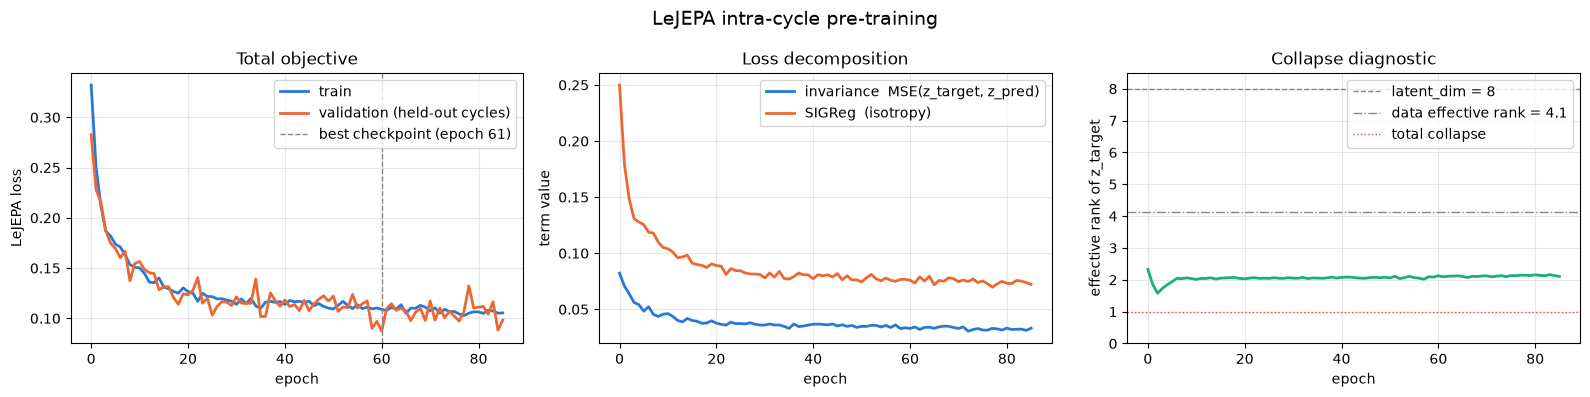

In [7]:
# =============================================================================
# STEP 3b: Pre-training diagnostics (three curves worth putting in the paper)
# =============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
best_ep = int(np.argmin(history['val']))

ax1.plot(history['train'], color=BLUE, lw=2, label='train')
ax1.plot(history['val'], color=ORANGE, lw=2, label='validation (held-out cycles)')
ax1.axvline(best_ep, ls='--', c=GRAY, lw=1, label=f'best checkpoint (epoch {best_ep + 1})')
ax1.set_xlabel('epoch'); ax1.set_ylabel('LeJEPA loss'); ax1.set_title('Total objective')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['invariance'], color=BLUE, lw=2, label='invariance  MSE(z_target, z_pred)')
ax2.plot(history['isotropy'], color=ORANGE, lw=2, label='SIGReg  (isotropy)')
ax2.set_xlabel('epoch'); ax2.set_ylabel('term value'); ax2.set_title('Loss decomposition')
ax2.legend(); ax2.grid(alpha=0.3)

ax3.plot(history['eff_rank'], color=GREEN, lw=2)
ax3.axhline(LATENT_DIM, ls='--', c=GRAY, lw=1, label=f'latent_dim = {LATENT_DIM}')
ax3.axhline(eff_rank_data, ls='-.', c=GRAY, lw=1, label=f'data effective rank = {eff_rank_data:.1f}')
ax3.axhline(1.0, ls=':', c=RED, lw=1, label='total collapse')
ax3.set_ylim(0, LATENT_DIM + 0.5)
ax3.set_xlabel('epoch'); ax3.set_ylabel('effective rank of z_target'); ax3.set_title('Collapse diagnostic')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('LeJEPA intra-cycle pre-training', fontsize=14)
plt.tight_layout(); plt.show()

### Explanation: STEP 3 and STEP 3b

| | |
| --- | --- |
| **What it does** | `pretrain_lejepa(X, seed)` holds out 15 % of the cycles (no labels involved), trains the encoder and predictor on the rest with the LeJEPA loss, evaluates the loss and the latent effective rank on the held-out cycles every epoch, stops early when the held-out loss has not improved for 25 epochs, and restores the best checkpoint. The cell then runs it once with `SEED` and reports. STEP 3b plots the curves. |
| **Input** | `X_tensor` (5232 × 26), the STEP 0 constants. |
| **Output** | Trained `encoder` and `predictor` (frozen from here on), `history` (per-epoch train loss, val loss, invariance, isotropy, effective rank), `info` (best epoch, stop epoch, time), `z_all` (5232 × 8 latents of the full cycles), `latent_eff_rank`. |
| **Why it exists** | This is where the model learns the sensor relationships of a normal cycle. The held-out split is what lets you tell "the loss went down because it learned" from "because it memorised". |

#### The setup

- **Held-out split.** 4448 cycles to train on, 784 held back. Labels are still
  untouched: we hold out *cycles* to check the self-supervised objective on data
  the model has not fitted.
- **`AdamW`**: Adam with proper weight decay, a mild pull of weights toward zero.
- **`CosineAnnealingLR`**: the learning rate starts at 3e-3 and eases down a cosine
  curve to ~0. Big steps early to explore, small steps late to settle.
- **`drop_last=True`** matters more than it looks: 4448 / 256 leaves a final batch
  of 96, and `sigreg` is a *statistical* test over the batch, so a short batch
  would give a noisy, biased estimate.

#### The loop

```python
opt.zero_grad()                              # 1. clear last batch's gradients
mask = sample_group_mask(len(xb))            #    fresh random block mask
z_context = enc(xb, mask)                    #    view 1: the visible blocks
z_target = encode_full(enc, xb)              #    view 2: the FULL cycle, same encoder
z_pred = pred(z_context)                     #    the guess
loss, inv, iso = lejepa_loss(...)            # 2. forward pass, build the graph
loss.backward()                              # 3. gradients for every weight
opt.step()                                   # 4. nudge every weight downhill
```

The four-line rhythm every PyTorch loop follows, with the LeJEPA-specific middle:
both views through the **same** encoder and the loss taking all three latents
**live**.

> **Why no `.detach()`?** Most JEPA-style code cuts gradient flow through the
> target branch to discourage collapse. LeJEPA's claim is that a real isotropy
> constraint makes that unnecessary, and the effective-rank curve verifies it here.
> The original draft had its worst bug at this spot: it computed the variance
> penalty *from the already-detached target*, so the term had
> `requires_grad=False` and contributed exactly zero gradient. **A regulariser
> computed on a detached tensor is dead code.** STEP 2b test (2) guards against it.

#### Validation and early stopping

The validation masks come from a **private generator** seeded from the run seed,
so the validation loss at epoch *e* uses the same masks every time the seed is
reused, and drawing them does not disturb the training stream. Standard early
stopping then keeps a snapshot of the best-scoring weights, stops after 25 epochs
without improvement, and **restores the snapshot** rather than keeping the last
epoch.

#### Reading the output

- `inv` (invariance): how well the predictor guesses. Falling: it is learning.
- `iso` (SIGReg): distance from an isotropic Gaussian. Falls more slowly, which
  says the invariance term dominates.
- `eff.rank`: should sit comfortably above 1. Values in the 2–3 range are expected
  given the data's rank of ~4. STEP 3b draws it with reference lines at 1 (collapse),
  at the data's own effective rank, and at `LATENT_DIM`.

The effective-rank panel is the one to check first: if that line dives toward 1,
stop and debug before trusting anything downstream.

**Questions you may get**

- *"How long does it take?"* About 20 s per run on 8 CPU threads; the printed
  `info` gives the exact time.
- *"Why early stopping if the loss is self-supervised?"* Because the model can still
  overfit the pretext task. The held-out cycles show whether the learned
  relationships generalise to cycles it has not seen.
- *"What is a good val loss?"* There is no absolute scale. Compare it with the
  train loss (they should be close) and watch that it stops improving rather than
  drifting up.

## STEP 4 — Active learning and downstream classification

Uncertainty is the latent prediction error averaged over several mask draws. The
random-300 baseline is not optional: without it, defect enrichment cannot be
attributed to the LeJEPA score rather than to the labelling budget itself. AUPRC
is the headline metric because at a 1.15 % defect rate the all-negative predictor
already scores ~99 % accuracy.

### The map of this phase

```
                  frozen encoder + frozen predictor  (from STEP 3)
                                    │
   X_tensor (5232 × 26)  ───────────┤
                                    ▼
   4.0  CHECK      the model being scored with is the trained one
   4.1  TRACE      the score computed by hand on one defect and one pass cycle
   4.2  SCORE      uncertainty[i] = mean over mask draws of ‖ z_target − z_pred ‖₂
                   (one number per cycle; NO labels used)  + enrichment curve
                                    ▼
   4.3  QUERY      the 300 cycles with the highest score go to the "human"
                   (the first and only place `y` is read for those 300)
                                    ▼
   4.4  TRAIN      RandomForest on the 300 RAW standardised sensor rows + labels
                   EVALUATE   AUPRC on the 4932 cycles that were never queried
                                    ▼
   4.5  CONTROL    repeat with 300 RANDOM cycles, 10 times
                                    ▼
   4.6  DIAGNOSE   (a) same test set for every strategy
                   (b) how much of the top-300 is mask-draw noise
                   (c) does the score beat a trivial anomaly score?
```

The phase is **single-shot**: score once, pick the top-300 once, train once. The
encoder is never retrained with labels. Keep that in mind when reading the word
"loop" in the architecture diagram.

### 4.0 — Sanity check: are we scoring with the trained model?

The classic notebook accident is a cell that re-creates `encoder` with fresh
weights. This cell compares the trained pair against an untrained pair on the same
cycles with the same mask, and stops the notebook if they look alike.

In [8]:
# =============================================================================
# STEP 4.0: Sanity check — the model we are about to score with IS the trained one
# =============================================================================
# Cheap insurance against the classic notebook accident (a cell re-creating
# `encoder` with fresh weights). Same 512 cycles and the same mask for both pairs.
untrained_encoder, untrained_predictor = LeJEPAEncoder(input_dim).eval(), LeJEPAPredictor().eval()
gen = torch.Generator().manual_seed(0)
x_check = X_tensor[torch.randperm(n_cycles, generator=gen)[:512]]
mask_check = sample_group_mask(len(x_check), generator=gen)

rows = []
with torch.no_grad():
    for name, enc, pred in [('trained (STEP 3)', encoder, predictor),
                            ('untrained (fresh init)', untrained_encoder, untrained_predictor)]:
        z_t = encode_full(enc, x_check)
        mse = torch.mean((z_t - pred(enc(x_check, mask_check))) ** 2).item()
        rows.append((name, mse, 100 * mse / z_t.var(dim=0).mean().item()))
print(f"{'model pair':<26}{'invariance MSE':>16}{'as % of latent variance':>26}")
for name, mse, rel in rows:
    print(f"{name:<26}{mse:>16.4f}{rel:>25.1f}%")
assert rows[0][2] < rows[1][2] / 3, "the encoder does not look trained: re-run STEP 3"
print("\nOK: the trained pair explains far more of the latent than a fresh one.")

model pair                  invariance MSE   as % of latent variance
trained (STEP 3)                    0.0425                     10.8%
untrained (fresh init)              0.0695                    288.1%

OK: the trained pair explains far more of the latent than a fresh one.


### 4.1 — The uncertainty score, traced on a single cycle

`latent_uncertainty()` does the following for **every** cycle `x`:

```
z_target = encode_full(encoder, x)      # 8-d summary of the FULL cycle. Computed once.
for draw in 1..10:
    mask   = sample_group_mask(...)     # hide a random subset of the 9 correlated blocks
    z_ctx  = encoder(x, mask)           # 8-d summary of the PARTIAL cycle
    z_pred = predictor(z_ctx)           # the predictor's guess of z_target from z_ctx
    error  = ‖ z_target − z_pred ‖₂     # Euclidean distance between two 8-d vectors
uncertainty = mean(error over the draws)
```

The claim behind it: the predictor learned, from 5232 unlabelled cycles, how the
blocks of a *normal* cycle relate to each other. If it can reconstruct the full
latent from a partial view, the cycle follows the usual physics. If it cannot, the
cycle is unlike the ones it learned from. That is the "epistemic uncertainty"
signal, and it costs zero labels. The cell runs the loop by hand on one **defect**
and one **pass** cycle, printing every draw.

In [9]:
# =============================================================================
# STEP 4.1: The uncertainty score, traced by hand on one cycle at a time
# =============================================================================
def trace_one_cycle(idx, n_draws=N_MASK_DRAWS, seed=0):
    """Run the body of latent_uncertainty() for a single cycle and print every draw."""
    x = X_tensor[idx:idx + 1]
    gen = torch.Generator().manual_seed(seed)
    with torch.no_grad():
        z_target = encode_full(encoder, x)
        tag = f"DEFECT  |  reason: {reason[idx]}" if y[idx] == 1 else "pass"
        print(f"cycle {idx}  |  label = {tag}")
        print(f"z_target (full cycle, {LATENT_DIM}-d): {z_target[0].numpy().round(3)}\n")
        print(f"{'draw':<6}{'hidden blocks (sensors)':<42}{'#hidden':>8}{'‖z_target − z_pred‖':>22}")
        errors = []
        for d in range(n_draws):
            mask = sample_group_mask(1, generator=gen)
            err = torch.norm(z_target - predictor(encoder(x, mask)), dim=1).item()
            errors.append(err)
            print(f"{d + 1:<6}{', '.join(describe_mask(mask[0])):<42}{int((mask[0] == 0).sum()):>8}{err:>22.4f}")
        errors = np.array(errors)
        print(f"\n-> uncertainty score = mean of {n_draws} draws = {errors.mean():.4f}"
              f"   (std across draws {errors.std():.4f}, min {errors.min():.3f}, max {errors.max():.3f})")
    return errors.mean()


defect_idx = int(np.where(y == 1)[0][0])      # the first recorded defect
pass_idx = int(np.where(y == 0)[0][0])        # the first pass cycle
print("=" * 90); print("  A DEFECT CYCLE"); print("=" * 90)
trace_one_cycle(defect_idx)
print("\n" + "=" * 90); print("  A PASS CYCLE"); print("=" * 90)
trace_one_cycle(pass_idx)
print("\nThe error swings with WHICH blocks are hidden (block 6 alone holds 15 of the 26 sensors),")
print("which is why one draw is not a score and several draws are averaged.")

  A DEFECT CYCLE
cycle 47  |  label = DEFECT  |  reason: 가스
z_target (full cycle, 8-d): [ 0.071 -0.616  0.084  0.111 -0.535 -0.209 -0.244  0.503]

draw  hidden blocks (sensors)                    #hidden   ‖z_target − z_pred‖
1     B2(2), B6(15), B8(1)                            18                0.3323
2     B1(2), B7(1), B8(1), B9(1)                       5                0.2471
3     B3(1), B4(2), B6(15), B8(1), B9(1)              20                0.2985
4     B5(1)                                            1                0.1642
5     B2(2), B3(1), B4(2), B5(1), B7(1)                7                0.3601
6     B2(2), B3(1), B6(15), B7(1), B8(1), B9(1)       21                0.5135
7     B1(2), B3(1), B7(1), B8(1)                       5                0.2077
8     B1(2), B2(2), B4(2), B5(1), B6(15), B7(1)       23                0.8746
9     B1(2), B2(2), B3(1), B4(2), B5(1), B7(1)         9                0.4160
10    B1(2), B2(2), B4(2), B8(1)                       7       

### 4.2 — Score every cycle, then check whether the defects sit in the tail

The real call to `acquisition_score()`. Nothing in it uses `y`. The labels are
used **afterwards, only for diagnosis**: a histogram of the score for pass versus
defect cycles, the rank of each of the 60 defects, and an **enrichment curve**
(defects inside the top-*k* for every budget *k*, against random sampling's
expected line and its 5–95 % band). The curve says far more than the single
budget-300 number and is the figure a reviewer will want.

acquisition_score(mode='mc') on 5232 cycles in 0.19 s: min 0.126, median 0.385, max 1.447
median score  pass 0.385  |  defect 0.315
ranks of the 60 defects (1 = most uncertain): [  9  10  11  13  22  25  79  90  93 387 493 514 551 617 952] ...
9 defects inside the top-300; random sampling would put 3.4 there on average.


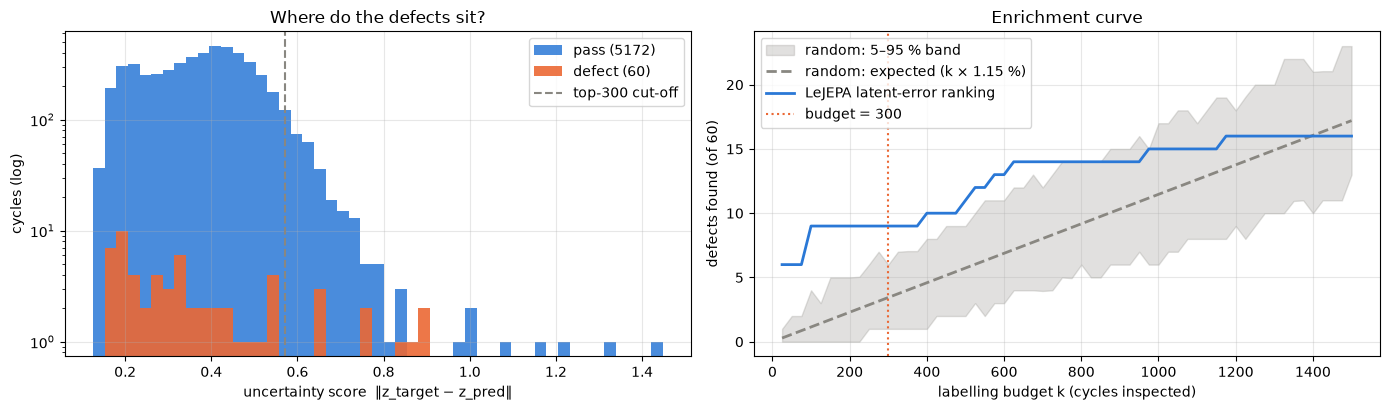

In [10]:
# =============================================================================
# STEP 4.2: Score every cycle (no labels), then diagnose the score (labels)
# =============================================================================
t0 = time.time()
uncertainty_scores = acquisition_score(encoder, predictor, X_tensor, mode=SCORING_MODE, seed=SEED)
print(f"acquisition_score(mode='{SCORING_MODE}') on {n_cycles} cycles in {time.time() - t0:.2f} s: "
      f"min {uncertainty_scores.min():.3f}, median {np.median(uncertainty_scores):.3f}, "
      f"max {uncertainty_scores.max():.3f}")

# ---- diagnosis with the labels (NOT part of the method) ---------------------
rank_desc = np.argsort(-uncertainty_scores)                      # most uncertain first
rank_of = np.empty(n_cycles, dtype=int); rank_of[rank_desc] = np.arange(1, n_cycles + 1)
defect_ranks = np.sort(rank_of[y == 1])
print(f"median score  pass {np.median(uncertainty_scores[y == 0]):.3f}  |  defect {np.median(uncertainty_scores[y == 1]):.3f}")
print(f"ranks of the {n_defects} defects (1 = most uncertain): {defect_ranks[:15]} ...")
print(f"{int((defect_ranks <= LABELING_BUDGET).sum())} defects inside the top-{LABELING_BUDGET}; "
      f"random sampling would put {LABELING_BUDGET * base_rate:.1f} there on average.")

# ---- enrichment curve --------------------------------------------------------
budgets = np.arange(25, 1501, 25)
found_lejepa = np.array([y[rank_desc[:k]].sum() for k in budgets])
rng_curve = np.random.RandomState(SEED)
rand_draws = np.array([[y[rng_curve.choice(n_cycles, k, replace=False)].sum() for k in budgets]
                       for _ in range(200)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2))
bins = np.linspace(uncertainty_scores.min(), uncertainty_scores.max(), 50)
ax1.hist(uncertainty_scores[y == 0], bins=bins, color=BLUE, alpha=0.85, label=f'pass ({n_cycles - n_defects})')
ax1.hist(uncertainty_scores[y == 1], bins=bins, color=ORANGE, alpha=0.9, label=f'defect ({n_defects})')
ax1.axvline(np.sort(uncertainty_scores)[-LABELING_BUDGET], color=GRAY, ls='--', lw=1.5,
            label=f'top-{LABELING_BUDGET} cut-off')
ax1.set_yscale('log'); ax1.set_xlabel('uncertainty score  ‖z_target − z_pred‖')
ax1.set_ylabel('cycles (log)'); ax1.set_title('Where do the defects sit?'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.fill_between(budgets, np.percentile(rand_draws, 5, axis=0), np.percentile(rand_draws, 95, axis=0),
                 color=GRAY, alpha=0.25, label='random: 5–95 % band')
ax2.plot(budgets, budgets * base_rate, color=GRAY, lw=2, ls='--', label=f'random: expected (k × {base_rate*100:.2f} %)')
ax2.plot(budgets, found_lejepa, color=BLUE, lw=2, label='LeJEPA latent-error ranking')
ax2.axvline(LABELING_BUDGET, color=ORANGE, ls=':', lw=1.5, label=f'budget = {LABELING_BUDGET}')
ax2.set_xlabel('labelling budget k (cycles inspected)'); ax2.set_ylabel(f'defects found (of {n_defects})')
ax2.set_title('Enrichment curve'); ax2.legend(loc='upper left'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.3 — Query: hand the 300 highest-scoring cycles to the oracle

`np.argsort` sorts ascending, so `[-300:]` is the 300 **largest** scores. This is
the moment the labels enter: in production a person inspects those 300 parts; here
the inspection is simulated by reading `y` for exactly those rows. The recorded
defect `reason` is printed alongside, and the queried defects are also counted in
**production events** (consecutive rows with the same reason are one event, e.g. a
start-up burst), because "11 defects" and "4 events" are different claims.

In [11]:
# =============================================================================
# STEP 4.3: The query — hand the 300 highest-scoring cycles to the oracle
# =============================================================================
query_indices = np.argsort(uncertainty_scores)[-LABELING_BUDGET:]     # the 300 LARGEST scores
X_active_learning = X_scaled[query_indices]                           # (300, 26) raw standardised sensors
y_active_learning = y[query_indices]                                  # (300,)   the oracle's answers
n_found = int(y_active_learning.sum())

print(f"Queried {LABELING_BUDGET} most uncertain cycles.")
print(f"Defects found in the query set: {n_found} ({n_found / LABELING_BUDGET * 100:.1f}% vs "
      f"{base_rate * 100:.2f}% base rate)  ->  enrichment x{n_found / (LABELING_BUDGET * base_rate):.1f}")
print(f"score threshold to be queried: {uncertainty_scores[query_indices].min():.4f}")

print(f"\n{'rank':<6}{'row':<7}{'score':>8}   {'label':<8}reason")
for r, i in enumerate(query_indices[::-1][:10], 1):
    print(f"{r:<6}{i:<7}{uncertainty_scores[i]:>8.4f}   {'DEFECT' if y[i] else 'pass':<8}{reason[i] if y[i] else ''}")

# Independent defects, or one production event?  Consecutive rows with the same
# reason are one event (e.g. start-up scrap); count both and report both.
q_def = np.sort(query_indices[y_active_learning == 1])
n_events = 1 + int((np.diff(q_def) > 5).sum()) if len(q_def) else 0
print(f"\nqueried defects by reason: {pd.Series(reason[q_def]).value_counts().to_dict()}")
print(f"row numbers              : {q_def.tolist()}")
print(f"-> {n_found} defective cycles in roughly {n_events} separate production event(s).")

Queried 300 most uncertain cycles.
Defects found in the query set: 9 (3.0% vs 1.15% base rate)  ->  enrichment x2.6
score threshold to be queried: 0.5719

rank  row       score   label   reason
1     1209     1.4474   pass    
2     1210     1.3214   pass    
3     1208     1.2241   pass    
4     1207     1.1519   pass    
5     3021     1.0867   pass    
6     3721     0.9996   pass    
7     1205     0.9909   pass    
8     1206     0.9627   pass    
9     2472     0.9040   DEFECT  초기허용불량
10    2471     0.8999   DEFECT  초기허용불량

queried defects by reason: {'초기허용불량': 9}
row numbers              : [2461, 2462, 2468, 2469, 2470, 2471, 2472, 2473, 2474]
-> 9 defective cycles in roughly 2 separate production event(s).


### 4.4 — Train the downstream classifier and evaluate it on the unqueried rest

`fit_and_score()` fits a `RandomForestClassifier` on the 300 **raw standardised
sensor rows** (not the 8-d latents, so that SHAP in STEP 5 speaks in sensor units),
with `class_weight='balanced_subsample'` to up-weight the rare defect class inside
every tree's bootstrap sample, and returns the **AUPRC** on the cycles that were
never queried. The cell also prints a *top-k inspection* table and the
precision–recall curve, which is what AUPRC means in practice, and the
classification report as a warning example.

training rows : 300  (defects: 9)
holdout rows  : 4932  (defects: 51)
holdout AUPRC : 0.0440   (chance = base rate = 0.0103)   [0.8 s]

If an operator re-inspects the k holdout cycles with the highest predicted defect probability:
     k  defects caught   of   precision   recall
    25               1   51       0.040    0.020
    50               3   51       0.060    0.059
   100               7   51       0.070    0.137
   200              10   51       0.050    0.196
   500              15   51       0.030    0.294
  1000              20   51       0.020    0.392


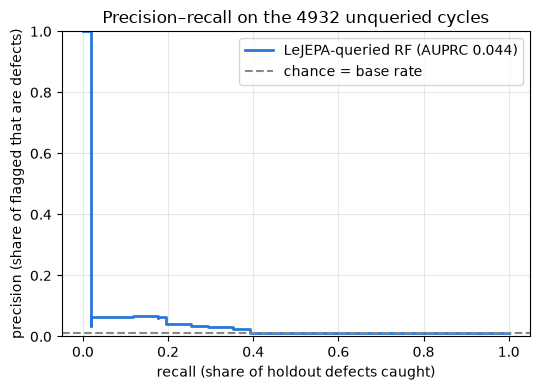

--- Classification report at the default 0.5 threshold (for reference only) ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4881
           1       1.00      0.02      0.04        51

    accuracy                           0.99      4932
   macro avg       0.99      0.51      0.52      4932
weighted avg       0.99      0.99      0.99      4932

Accuracy is ~0.99 no matter what; read the defect row's recall. This is why AUPRC is the metric.


In [12]:
# =============================================================================
# STEP 4.4: Downstream classifier on the RAW sensors, evaluated by AUPRC
# =============================================================================
def fit_and_score(query_idx, holdout_idx=None, rf_seed=SEED):
    """Train the downstream RandomForest on a labelling budget and score the rest.

    holdout_idx=None: holdout = every cycle NOT queried (the 04 protocol).
    An explicit holdout is used by the fixed-test-set comparison in STEP 4.6a.
    Returns (classifier, holdout indices, holdout AUPRC).
    """
    holdout = np.setdiff1d(np.arange(n_cycles), query_idx) if holdout_idx is None else holdout_idx
    clf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=rf_seed,
                                 class_weight='balanced_subsample', n_jobs=RF_N_JOBS)
    clf.fit(X_scaled[query_idx], y[query_idx])
    if len(clf.classes_) == 1:                  # a budget with zero defects: single-class forest
        proba = np.zeros(len(holdout))
    else:
        proba = clf.predict_proba(X_scaled[holdout])[:, 1]
    # AUPRC, not accuracy/F1: at a 1.15% defect rate the all-negative predictor already
    # scores ~99% accuracy, and a thresholded F1 on ~50 positives is dominated by noise.
    return clf, holdout, average_precision_score(y[holdout], proba)


t0 = time.time()
clf, unqueried_indices, auprc_active = fit_and_score(query_indices)
proba_active = clf.predict_proba(X_scaled[unqueried_indices])[:, 1]
n_pos_holdout = int(y[unqueried_indices].sum())
print(f"training rows : {len(query_indices)}  (defects: {n_found})")
print(f"holdout rows  : {len(unqueried_indices)}  (defects: {n_pos_holdout})")
print(f"holdout AUPRC : {auprc_active:.4f}   (chance = base rate = {y[unqueried_indices].mean():.4f})   "
      f"[{time.time() - t0:.1f} s]")

# ---- what AUPRC means operationally: inspect the k most suspicious holdout cycles
order = np.argsort(-proba_active)
print(f"\nIf an operator re-inspects the k holdout cycles with the highest predicted defect probability:")
print(f"{'k':>6}{'defects caught':>16}{'of':>5}{'precision':>12}{'recall':>9}")
for k in [25, 50, 100, 200, 500, 1000]:
    caught = int(y[unqueried_indices][order[:k]].sum())
    print(f"{k:>6}{caught:>16}{n_pos_holdout:>5}{caught / k:>12.3f}{caught / n_pos_holdout:>9.3f}")

prec, rec, _ = precision_recall_curve(y[unqueried_indices], proba_active)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.step(rec, prec, where='post', color=BLUE, lw=2, label=f'LeJEPA-queried RF (AUPRC {auprc_active:.3f})')
ax.axhline(y[unqueried_indices].mean(), color=GRAY, ls='--', lw=1.5, label='chance = base rate')
ax.set_xlabel('recall (share of holdout defects caught)'); ax.set_ylabel('precision (share of flagged that are defects)')
ax.set_ylim(0, 1); ax.set_title(f'Precision–recall on the {len(unqueried_indices)} unqueried cycles')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ---- the trap: a thresholded report looks fine and says almost nothing -------
print("--- Classification report at the default 0.5 threshold (for reference only) ---")
print(classification_report(y[unqueried_indices], clf.predict(X_scaled[unqueried_indices]), zero_division=0))
print("Accuracy is ~0.99 no matter what; read the defect row's recall. This is why AUPRC is the metric.")

### 4.5 — The control: 300 *random* cycles, 10 times

Random sampling of 300 finds 300 × 1.15 % ≈ 3.5 defects on average. The claim is
the **gap** between the LeJEPA query and that number; drawing the random budget 10
times gives the baseline's spread so the gap can be judged against the noise. The
table has the same format as the 04 notebook so the numbers compare directly.

In [13]:
# =============================================================================
# STEP 4.5: The control — the same budget spent on RANDOM cycles, 10 times
# =============================================================================
rng = np.random.RandomState(SEED)
rand_defects, rand_auprc = [], []
print(f"{'draw':<6}{'defects in budget':>18}{'holdout AUPRC':>16}")
for d in range(N_RANDOM_BASELINE_DRAWS):
    rand_idx = rng.choice(n_cycles, LABELING_BUDGET, replace=False)
    rand_defects.append(int(y[rand_idx].sum()))
    rand_auprc.append(fit_and_score(rand_idx)[2])
    print(f"{d + 1:<6}{rand_defects[-1]:>18}{rand_auprc[-1]:>16.4f}")

print(f"\n--- Active learning vs random sampling (budget = {LABELING_BUDGET}, seed {SEED}) ---")
print(f"{'strategy':<24}{'defects labelled':>18}{'holdout AUPRC':>18}")
print(f"{'LeJEPA latent error':<24}{n_found:>18}{auprc_active:>18.4f}")
print(f"{'random (10 draws)':<24}{np.mean(rand_defects):>13.1f} +- {np.std(rand_defects):<3.1f}"
      f"{np.mean(rand_auprc):>12.4f} +- {np.std(rand_auprc):.4f}")
print("\nOne seed is not evidence: the enrichment gap is large, the AUPRC gap needs STEP 6's error bars.")

draw   defects in budget   holdout AUPRC
1                      4          0.0494
2                      2          0.2298
3                      3          0.0674
4                      2          0.0200
5                      6          0.0415
6                      2          0.0374
7                      4          0.1051
8                      5          0.0906
9                      4          0.0679
10                     4          0.2005

--- Active learning vs random sampling (budget = 300, seed 42) ---
strategy                  defects labelled     holdout AUPRC
LeJEPA latent error                      9            0.0440
random (10 draws)                 3.6 +- 1.3      0.0910 +- 0.0668

One seed is not evidence: the enrichment gap is large, the AUPRC gap needs STEP 6's error bars.


### 4.6 — Diagnostics (additions to the 04 protocol)

Three things a careful reviewer will ask about, each in its own cell so it can be
adopted or discarded independently:

- **(a) Same test set for every strategy.** In the 04 protocol the holdout is
  "everything not queried", so the LeJEPA classifier and each random classifier are
  evaluated on *different* cycles with different numbers of defects. A stratified
  test set fixed *before* querying makes the comparison apples to apples.
- **(b) Exact expectation over all 510 block masks.** Under `keep_prob = 0.5`
  every admissible mask is equally likely, so the mean over all of them is the
  exact quantity that 10 draws estimate. Comparing the two shows how much of the
  top-300 was decided by the mask seed rather than by the cycle, and yields a
  per-block sensitivity as a by-product.
- **(c) Trivial anomaly baselines.** The sensor block has effective rank ~4. Does
  the LeJEPA score find more defects than "distance from the PCA subspace" or plain
  "distance from the mean cycle"? If not, the acquisition function behaves like a
  generic outlier detector on this dataset, which the paper must either state or
  answer. STEP 6 repeats this check over seeds.

In [14]:
# =============================================================================
# STEP 4.6a (diagnostic): judge every strategy on the SAME held-out test set
# =============================================================================
# In the 04 protocol each strategy is evaluated on "everything it did not query",
# i.e. on different cycles with different numbers of defects. Here a stratified
# test set is fixed BEFORE querying and every classifier is scored on it.
TEST_FRAC = 0.25
pool_idx, test_idx = train_test_split(np.arange(n_cycles), test_size=TEST_FRAC, stratify=y, random_state=SEED)
print(f"pool (available to query): {len(pool_idx)} cycles, {int(y[pool_idx].sum())} defects")
print(f"fixed test set           : {len(test_idx)} cycles, {int(y[test_idx].sum())} defects (identical for all)")

pool_query = pool_idx[np.argsort(uncertainty_scores[pool_idx])[-LABELING_BUDGET:]]
_, _, auprc_fixed_lejepa = fit_and_score(pool_query, holdout_idx=test_idx)

rng = np.random.RandomState(SEED)
fixed_rand_defects, fixed_rand_auprc = [], []
for _ in range(N_RANDOM_BASELINE_DRAWS):
    ridx = rng.choice(pool_idx, LABELING_BUDGET, replace=False)
    fixed_rand_defects.append(int(y[ridx].sum()))
    fixed_rand_auprc.append(fit_and_score(ridx, holdout_idx=test_idx)[2])

print(f"\n--- Same {len(test_idx)}-cycle test set, budget {LABELING_BUDGET} drawn from the pool ---")
print(f"{'strategy':<24}{'defects labelled':>18}{'test AUPRC':>18}")
print(f"{'LeJEPA latent error':<24}{int(y[pool_query].sum()):>18}{auprc_fixed_lejepa:>18.4f}")
print(f"{'random (10 draws)':<24}{np.mean(fixed_rand_defects):>13.1f} +- {np.std(fixed_rand_defects):<3.1f}"
      f"{np.mean(fixed_rand_auprc):>12.4f} +- {np.std(fixed_rand_auprc):.4f}")
print(f"chance level on this test set: {y[test_idx].mean():.4f}   "
      f"(only {int(y[test_idx].sum())} test defects, so still noisy; but now apples to apples)")

pool (available to query): 3924 cycles, 45 defects
fixed test set           : 1308 cycles, 15 defects (identical for all)

--- Same 1308-cycle test set, budget 300 drawn from the pool ---
strategy                  defects labelled        test AUPRC
LeJEPA latent error                      7            0.4995
random (10 draws)                 3.0 +- 1.3      0.1429 +- 0.0858
chance level on this test set: 0.0115   (only 15 test defects, so still noisy; but now apples to apples)


In [15]:
# =============================================================================
# STEP 4.6b (diagnostic): how much of the top-300 is decided by the mask draw?
# =============================================================================
t0 = time.time()
exact_scores, per_mask_err, keep_patterns = latent_uncertainty_exact(encoder, predictor, X_tensor, return_details=True)
print(f"exact score over {per_mask_err.shape[0]} masks x {n_cycles} cycles in {time.time() - t0:.1f} s; "
      f"defects in its top-{LABELING_BUDGET}: {int(y[np.argsort(exact_scores)[-LABELING_BUDGET:]].sum())}")

top_exact = set(np.argsort(exact_scores)[-LABELING_BUDGET:])
print(f"\n{'mc seed':<10}{'Spearman vs exact':>18}{'top-300 overlap with exact':>28}{'defects in its top-300':>24}")
for s in range(5):
    mc = latent_uncertainty(encoder, predictor, X_tensor, generator=torch.Generator().manual_seed(s))
    top_mc = set(np.argsort(mc)[-LABELING_BUDGET:])
    print(f"{s:<10}{spearmanr(mc, exact_scores).correlation:>18.3f}{len(top_mc & top_exact):>24}/{LABELING_BUDGET}"
          f"{int(y[list(top_mc)].sum()):>20}")
print(f"\nWhatever share of the top-{LABELING_BUDGET} is NOT shared with the exact ranking was decided by the")
print("mask seed rather than by the cycle. SCORING_MODE = 'exact' in STEP 0 removes that noise.")

# ---- by-product: which block makes a cycle unpredictable? --------------------
hidden = (keep_patterns == 0)
block_effect = torch.stack([per_mask_err[hidden[:, g]].mean(0) - per_mask_err[~hidden[:, g]].mean(0)
                            for g in range(N_GROUPS)], dim=1).numpy()          # (n_cycles, N_GROUPS)
hdr = "".join(f"{f'B{b}({n})':>10}" for b, n in zip(BLOCK_IDS, BLOCK_SIZE))
print(f"\nerror increase when a block is hidden (mean over cycles):\n{'':<18}{hdr}")
for name, sel in [('defects', y == 1), ('passes', y == 0)]:
    print(f"{name:<18}" + "".join(f"{v:>10.3f}" for v in block_effect[sel].mean(0)))

exact score over 510 masks x 5232 cycles in 4.4 s; defects in its top-300: 10

mc seed    Spearman vs exact  top-300 overlap with exact  defects in its top-300
0                      0.911                     194/300                  10
1                      0.908                     197/300                   9
2                      0.907                     190/300                  12
3                      0.906                     199/300                   9
4                      0.911                     187/300                  10

Whatever share of the top-300 is NOT shared with the exact ranking was decided by the
mask seed rather than by the cycle. SCORING_MODE = 'exact' in STEP 0 removes that noise.

error increase when a block is hidden (mean over cycles):
                       B1(2)     B2(2)     B3(1)     B4(2)     B5(1)    B6(15)     B7(1)     B8(1)     B9(1)
defects                0.072     0.105     0.020     0.169     0.082     0.229     0.083     0.013     0.000
pa

In [16]:
# =============================================================================
# STEP 4.6c (diagnostic): does the LeJEPA score beat a trivial anomaly score?
# =============================================================================
pca_k = max(1, int(round(eff_rank_data)))                       # the data's own effective rank (~4)
pca = PCA(n_components=pca_k, random_state=SEED).fit(X_scaled)
pca_recon_err = np.linalg.norm(X_scaled - pca.inverse_transform(pca.transform(X_scaled)), axis=1)
l2_norm = np.linalg.norm(X_scaled, axis=1)                      # distance from the average cycle

candidates = {
    f'LeJEPA latent error ({SCORING_MODE})': uncertainty_scores,
    'LeJEPA latent error (exact)': exact_scores,
    f'PCA({pca_k}) reconstruction error': pca_recon_err,
    '‖x‖ distance from mean cycle': l2_norm,
}
print(f"{'ranking score':<34}{'defects in top-300':>20}{'events':>8}{'AP of score as detector':>26}")
for name, s in candidates.items():
    top = np.sort(np.argsort(s)[-LABELING_BUDGET:])
    d = top[y[top] == 1]
    ev = 1 + int((np.diff(d) > 5).sum()) if len(d) else 0
    print(f"{name:<34}{int(y[top].sum()):>20}{ev:>8}{average_precision_score(y, s):>26.4f}")
print(f"{'random expectation':<34}{LABELING_BUDGET * base_rate:>20.1f}{'':>8}{base_rate:>26.4f}")
print(f"\nSpearman(LeJEPA exact, PCA recon err) = {spearmanr(exact_scores, pca_recon_err).correlation:+.3f}")
print(f"Spearman(LeJEPA exact, ‖x‖)           = {spearmanr(exact_scores, l2_norm).correlation:+.3f}")
print("\nIf a trivial score finds as many defects as LeJEPA, the acquisition function is behaving like a")
print("generic outlier detector on this dataset. STEP 6 repeats this comparison over several seeds.")

ranking score                       defects in top-300  events   AP of score as detector
LeJEPA latent error (mc)                             9       2                    0.0366
LeJEPA latent error (exact)                         10       1                    0.0454
PCA(4) reconstruction error                         16       3                    0.0689
‖x‖ distance from mean cycle                        11       9                    0.0353
random expectation                                 3.4                            0.0115

Spearman(LeJEPA exact, PCA recon err) = +0.489
Spearman(LeJEPA exact, ‖x‖)           = -0.546

If a trivial score finds as many defects as LeJEPA, the acquisition function is behaving like a
generic outlier detector on this dataset. STEP 6 repeats this comparison over several seeds.


### Explanation: STEP 4, part by part

Every part is described with the same four questions. Variable flow at the end.

#### 4.0 — Sanity check

| | |
| --- | --- |
| **What it does** | Builds a fresh untrained encoder/predictor, evaluates the invariance MSE of both pairs on the same 512 cycles with the same mask, prints both and asserts the trained pair is much better. |
| **Input** | `encoder`, `predictor`, `X_tensor`, `sample_group_mask`. |
| **Output** | A two-row table; an `AssertionError` if the model does not look trained. |
| **Why it exists** | In the debug notebook (05) the trained model *was* silently replaced by an untrained one, and the phase reported 2 defects in 300, below the base rate, without any error. Ten lines of checking prevent a wrong table in the paper. |

*"Why is the trained MSE not zero?"* The predictor sees only part of the cycle.
Some information in the hidden blocks cannot be inferred from the visible ones, so
a floor remains. That floor, per cycle, is exactly the score in 4.1.

#### 4.1 — One cycle by hand

| | |
| --- | --- |
| **What it does** | `trace_one_cycle(idx)` executes the body of `latent_uncertainty()` for one cycle and prints, for each of the 10 draws, the hidden blocks (`describe_mask`), how many sensors were hidden, and the error. Then the mean (the score), std, min and max. Run on the first recorded defect and the first pass cycle. |
| **Input** | One row of `X_tensor`, the trained networks, `GROUP_MATRIX`, `N_MASK_DRAWS`. |
| **Output** | Printed trace; returns the score. |
| **Why it exists** | To make the score concrete. It is not a probability or a classifier output; it is a Euclidean distance between two 8-d vectors. Seeing ten draws also shows *why* averaging is needed: the error swings by a factor of several depending on which blocks were hidden. |

*"Why does hiding block 6 hurt so much?"* Block 6 holds 15 of the 26 sensors (all
timing signals and most barrel temperatures). Hiding it removes most of the
context. That is a property of the data's correlation structure, not a bug.

#### 4.2 — Score all cycles and diagnose

| | |
| --- | --- |
| **What it does** | Calls `acquisition_score()` once for all 5232 cycles with a seeded generator, then (diagnosis only) uses `y` to place the defects: score medians per class, the rank of every defect, how many are in the top-300, a histogram and the enrichment curve against 200 random rankings. |
| **Input** | `X_tensor`, trained networks, `SCORING_MODE`, `SEED`; for diagnosis `y`. |
| **Output** | `uncertainty_scores` (5232 numbers), `rank_of[i]` (1 = most uncertain), `defect_ranks`, two figures. |
| **Why it exists** | The method needs only the scores. The diagnosis exists because "n defects in 300" is one point on a curve; the curve shows whether the advantage is a tail effect or a general shift, and at which budget it saturates. |

*"Does the score use the labels?"* No. `y` is touched only after the score is
computed, to draw the figures. In production you would not have `y` at all here.

#### 4.3 — Query

| | |
| --- | --- |
| **What it does** | Takes the 300 largest scores, reads their labels and reasons (the simulated inspection), prints the top-10 with the oracle's answers, and counts the queried defects both as cycles and as production events. |
| **Input** | `uncertainty_scores`, `LABELING_BUDGET`, `X_scaled`, `y`, `reason`. |
| **Output** | `query_indices` (300 row numbers), `X_active_learning` (300 × 26), `y_active_learning` (300), `n_found`, `n_events`. |
| **Why it exists** | This is the only place labels enter the method, and the cheapest place to sanity-check the claim: the reasons and row numbers tell you whether the enrichment comes from many independent defects or from one burst. |

*"Why the raw sensors and not the latent for the classifier?"* So that SHAP in
STEP 5 explains decisions in physical sensor units an operator can act on. The
latent is used only to *choose* which cycles to label.

#### 4.4 — Classifier and AUPRC

| | |
| --- | --- |
| **What it does** | `fit_and_score(query_idx, holdout_idx=None, rf_seed)`: holdout = every row not queried unless one is given; fit a 300-tree balanced Random Forest on the queried rows using all CPU cores; return the forest, the holdout indices and the AUPRC. Guards against a budget with zero defects. Then the top-k table, the PR curve and the classification report. |
| **Input** | `query_indices`, `X_scaled`, `y`, `SEED`. |
| **Output** | `clf`, `unqueried_indices` (4932), `auprc_active`, `proba_active`. |
| **Why it exists** | Enrichment says how many defects were *labelled*; AUPRC says whether those labels produced a classifier that *generalises* to cycles nobody looked at. Different claims, both needed. |

*"Why not accuracy or F1?"* With 1.15 % defects a model that says "pass" for
everything scores ~99 % accuracy. F1 depends on one threshold and ~50 positives,
so it is dominated by noise. AUPRC uses the probabilities across all thresholds; its
chance level is the base rate (~0.01), not 0.5. The top-k table is the operational
reading: "if the operator re-inspects the k most suspicious holdout cycles, how
many of the holdout defects are caught?"

#### 4.5 — Random control

| | |
| --- | --- |
| **What it does** | Draws 300 rows uniformly without replacement ten times with a seeded `RandomState` and runs `fit_and_score` on each. Prints the per-draw values and the comparison table. |
| **Input** | `LABELING_BUDGET`, `y`, `SEED`, `fit_and_score`. |
| **Output** | `rand_defects`, `rand_auprc` (10 each), the table. |
| **Why it exists** | "11 defects in 300" means nothing on its own. The claim is the gap against ~3.5, and the 10 draws give the spread. |

#### 4.6a — Same holdout for every strategy

| | |
| --- | --- |
| **What it does** | `train_test_split(..., stratify=y)` fixes a 25 % test set before querying; LeJEPA's top-300 is taken from the remaining pool; ten random draws come from the same pool; every classifier is scored on the same test set. |
| **Input** | `uncertainty_scores`, `y`, `SEED`. |
| **Output** | `pool_idx`, `test_idx`, `pool_query`, `auprc_fixed_lejepa`, `fixed_rand_defects`, `fixed_rand_auprc`. |
| **Why it exists** | In the 04 protocol the LeJEPA query removes ~10 defects from *its* test set while a random query removes ~3 from *its* test set. A fixed test set is the cleaner comparison; its cost is fewer test defects (15), so it is noisier per seed. |

#### 4.6b — Exact expectation over all 510 masks

| | |
| --- | --- |
| **What it does** | `latent_uncertainty_exact(..., return_details=True)` evaluates the error under every admissible mask (510 × 5232 matrix). Re-draws the 10-mask estimator with 5 seeds and reports Spearman correlation with the exact score, overlap of the top-300, and defects found. Then, per block, the mean error increase when that block is hidden. |
| **Input** | Trained networks, `X_tensor`, `GROUP_MATRIX`. |
| **Output** | `exact_scores`, `per_mask_err`, `keep_patterns`, `block_effect` (5232 × 9). |
| **Why it exists** | It is the same score with the Monte-Carlo approximation removed: deterministic, 0.5 s, and it quantifies how much of the query set the 10-draw version leaves to chance. With 9 blocks enumeration is cheap; with many more blocks you would sample again. |

#### 4.6c — Trivial baselines

| | |
| --- | --- |
| **What it does** | Builds two label-free scores that need no network (PCA reconstruction error with as many components as the data's effective rank, and ‖x‖), ranks all cycles by each, and reports defects and events in the top-300 plus each score's average precision as a stand-alone detector and its rank correlation with the LeJEPA score. |
| **Input** | `X_scaled`, `y`, `uncertainty_scores`, `exact_scores`. |
| **Output** | `pca_recon_err`, `l2_norm`, `pca_k`, a table. |
| **Why it exists** | The paper's second novelty claim is that the *self-supervised prediction error* is a useful acquisition function. A reviewer will ask whether any outlier score would do the same. This is the cheapest way to find out, and STEP 6 gives it error bars. |

#### The variables that flow between the parts

```
encoder, predictor ──4.2──> uncertainty_scores (5232)
                                   │
                        4.3 ───────┴──> query_indices (300), X_active_learning, y_active_learning
                                                   │
                        4.4 ───────────────────────┴──> clf, unqueried_indices (4932), auprc_active
                        4.5 ─── random draws ─────────> rand_defects, rand_auprc      (control)
                        4.6a ── fixed test set ───────> auprc_fixed_lejepa, fixed_rand_auprc
                        4.6b ── all 510 masks ────────> exact_scores, block_effect
                        4.6c ── PCA / norm ───────────> pca_recon_err, l2_norm, pca_k
```

STEP 5 (SHAP) and STEP 7 (expert study) consume `clf` and `X_active_learning`
from 4.3–4.4. STEP 6 reuses `fit_and_score` and `pca_recon_err`. The other 4.6
outputs are diagnostics.

#### What to take away from STEP 4

- The phase is single-shot: one score per cycle, one top-300 query, one classifier.
- The score is a **distance in the 8-d latent** between "what the full cycle looks
  like" and "what the predictor expected from a partial view". It is comparable
  across cycles only because SIGReg made the latent isotropic.
- **Defect enrichment** is the robust result. **Holdout AUPRC** is noisy at one seed
  and must be reported as mean ± sd over seeds (STEP 6).
- Look at **which** defects were enriched. Consecutive rows with the same reason are
  one production event. The reasons in this dataset are `가스` (gas marks),
  `미성형` (short shot) and `초기허용불량` (start-up scrap tolerated at the beginning
  of a run).
- If the trivial baselines in 4.6c match LeJEPA, say so in the paper and treat it as
  a result to address, not a bug.

## STEP 5 — Explainability (SHAP) on the physical sensors

The classifier was trained on the **raw standardised sensors**, not on the latent,
so SHAP attributions land on quantities an operator can act on. SHAP values are
computed once (STEP 5) and reused by the beeswarm (5a), the operating window (5b)
and the expert packet (7a).

In [17]:
# =============================================================================
# STEP 5: SHAP values on the RAW physical sensors (positive = "defect" class)
# =============================================================================
def shap_positive(model, data):
    """2-D (rows, sensors) SHAP matrix for the positive class, whatever the shap version returns."""
    vals = shap.TreeExplainer(model).shap_values(data)
    if isinstance(vals, list):                  # older shap: one array per class
        return np.asarray(vals[1])
    vals = np.asarray(vals)
    return vals[:, :, 1] if vals.ndim == 3 else vals   # shap >= 0.45: (rows, sensors, classes)


t0 = time.time()
shap_values_pos = shap_positive(clf, X_active_learning)
assert shap_values_pos.shape == X_active_learning.shape, shap_values_pos.shape
X_al_df = pd.DataFrame(X_active_learning, columns=feature_names)

shap_abs_mean = np.abs(shap_values_pos).mean(axis=0)
importance_df = (pd.DataFrame({'Feature': feature_names, 'Importance': shap_abs_mean,
                               'Block': [block_of[f] for f in feature_names]})
                 .sort_values('Importance', ascending=True))
block_importance = importance_df.groupby('Block')['Importance'].sum().sort_values(ascending=False)

print(f"SHAP values: {shap_values_pos.shape} (queried cycles x sensors), positive class  [{time.time() - t0:.1f} s]")
print("\nTop 5 sensors by mean |SHAP|:")
for _, r in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {r['Feature']:<28} {r['Importance']:.4f}   (block {r['Block']})")
print("\nSummed by correlated block (the identifiable quantity):")
for b, v in block_importance.head(4).items():
    print(f"  block {b} ({BLOCK_SIZE[list(BLOCK_IDS).index(b)]} sensors): {v:.4f}")

SHAP values: (300, 26) (queried cycles x sensors), positive class  [0.1 s]

Top 5 sensors by mean |SHAP|:
  Filling_Time                 0.0988   (block 6)
  Max_Injection_Speed          0.0825   (block 6)
  Injection_Time               0.0782   (block 6)
  Max_Switch_Over_Pressure     0.0631   (block 6)
  Mold_Temperature_3           0.0343   (block 2)

Summed by correlated block (the identifiable quantity):
  block 6 (15 sensors): 0.3697
  block 2 (2 sensors): 0.0630
  block 4 (2 sensors): 0.0425
  block 5 (1 sensors): 0.0285


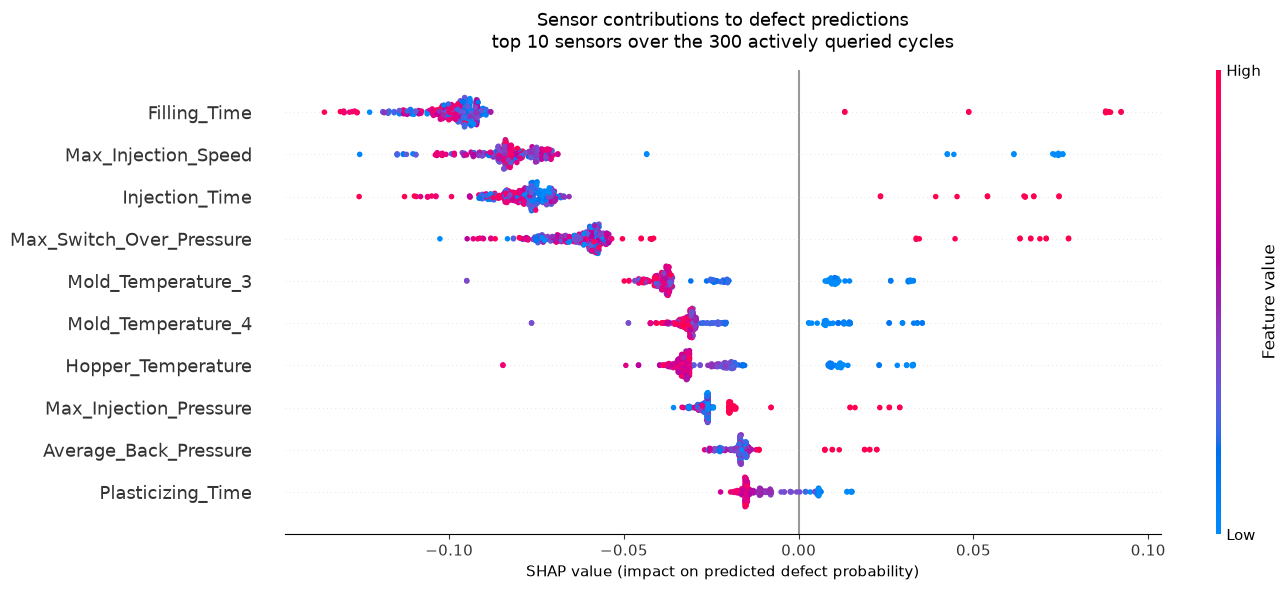

In [18]:
# =============================================================================
# STEP 5a: Beeswarm — per-cycle attributions for the 10 most influential sensors
# =============================================================================
fig = plt.figure(figsize=(14, 6))
ax = plt.gca()
shap.summary_plot(shap_values_pos, X_al_df, max_display=10, plot_size=None, show=False)
plt.title("Sensor contributions to defect predictions\n"
          f"top 10 sensors over the {LABELING_BUDGET} actively queried cycles", fontsize=13, pad=16)
ax.set_xlabel("SHAP value (impact on predicted defect probability)", fontsize=11)
plt.tight_layout(); plt.show()

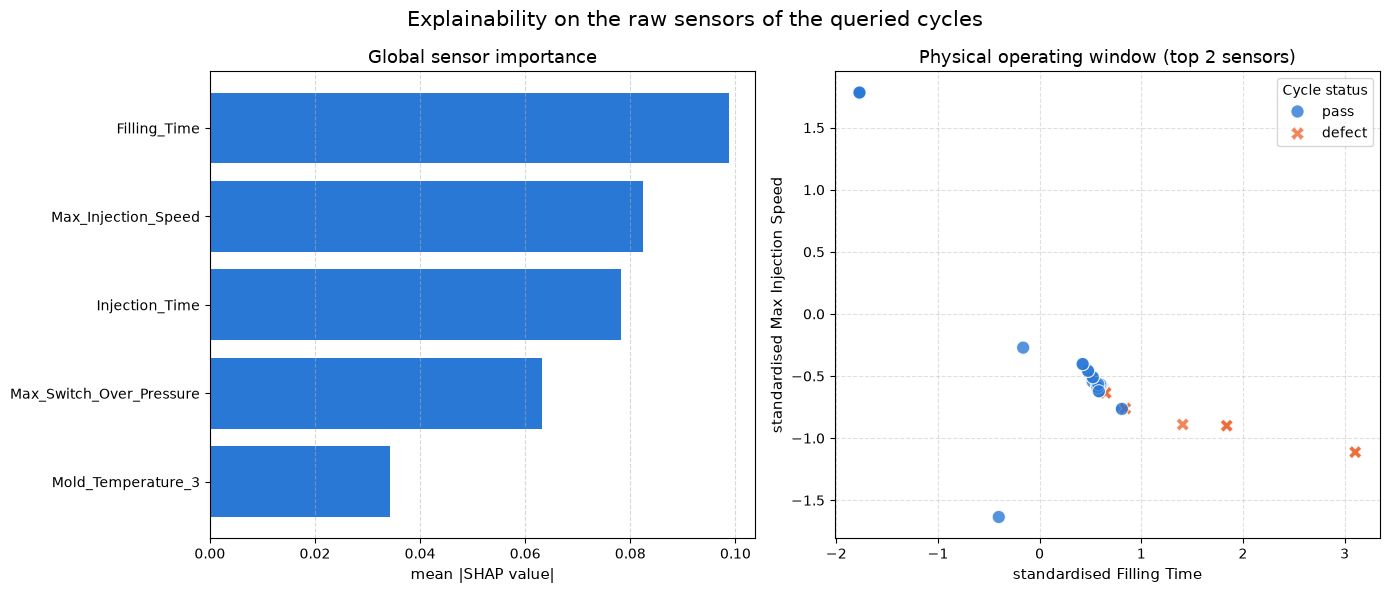

In [19]:
# =============================================================================
# STEP 5b: Global importance and the physical operating window
# =============================================================================
top5_df = importance_df.tail(5)
feat_x, feat_y = importance_df['Feature'].iloc[-1], importance_df['Feature'].iloc[-2]

plot_df = X_al_df.copy()
plot_df['Cycle status'] = np.where(y_active_learning == 1, 'defect', 'pass')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(top5_df['Feature'], top5_df['Importance'], color=BLUE)
ax1.set_xlabel('mean |SHAP value|', fontsize=11); ax1.set_title('Global sensor importance', fontsize=13)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

sns.scatterplot(data=plot_df, x=feat_x, y=feat_y, hue='Cycle status', hue_order=['pass', 'defect'],
                palette={'pass': BLUE, 'defect': ORANGE}, style='Cycle status',
                markers={'pass': 'o', 'defect': 'X'}, s=90, alpha=0.8, ax=ax2)
ax2.set_title('Physical operating window (top 2 sensors)', fontsize=13)
ax2.set_xlabel(f"standardised {feat_x.replace('_', ' ')}", fontsize=11)
ax2.set_ylabel(f"standardised {feat_y.replace('_', ' ')}", fontsize=11)
ax2.grid(linestyle='--', alpha=0.4)
plt.suptitle('Explainability on the raw sensors of the queried cycles', fontsize=15)
plt.tight_layout(); plt.show()

### Explanation: STEP 5, 5a, 5b

| | |
| --- | --- |
| **What it does** | `shap_positive()` runs `TreeExplainer` on the forest and returns one SHAP value per queried cycle per sensor for the "defect" class, whatever the installed `shap` version returns. STEP 5 aggregates them into a global ranking (per sensor and per correlated block); 5a draws the beeswarm; 5b draws the top-5 bar chart and the 2-D operating window on the two most influential sensors. |
| **Input** | `clf`, `X_active_learning` (300 × 26), `feature_names`, `block_of`, `y_active_learning`. |
| **Output** | `shap_values_pos` (300 × 26), `importance_df`, `block_importance`, `feat_x`, `feat_y`, three figures. |
| **Why it exists** | Without it the pipeline ends in a probability. This step turns the decision into "these sensors, at these values, pushed this cycle toward defect", in engineering units. |

#### What SHAP is, briefly

A trained forest is a black box. **SHAP** opens one prediction at a time: for a
single cycle it hands you a number per sensor saying "starting from the average
prediction, `Filling_Time` pushed this cycle's defect probability **up** by 0.09,
`Mold_Temperature_3` pushed it **down** by 0.02, ...". The numbers are additive
and signed. `TreeExplainer` computes them exactly and quickly for tree models.

#### The version dance

Older `shap` returns a *list* of two arrays (one per class); `shap` ≥ 0.45 returns
one 3-D array `(cycles, sensors, classes)`. Either way we want index 1, the
"defect" class, and the `assert` guarantees a `(300, 26)` matrix so a silent shape
mistake cannot poison the plots.

#### Global importance, per sensor and per block

Take the **absolute** value (how much a sensor moves the prediction, not which
way) and average over cycles. Because 19 of 26 sensors have a >0.9 twin, *which*
member of a block the forest leans on is close to arbitrary, so the cell also sums
|SHAP| **within each correlated block**: that is the quantity the data can
actually identify, and it is what the expert is shown in STEP 7.

#### Reading the beeswarm (5a)

Each row is a sensor, most important at the top; each dot is one cycle. Horizontal
position = the SHAP value (right = pushed toward defect); colour = the sensor's
actual value (red high, blue low). Look for colour separation along the x-axis: red
on the right means "**high** values of this sensor drive defects", a directly
actionable statement.

#### The operating window (5b)

Scatter the queried cycles in the plane of the two top sensors, pass versus
defect. If defects cluster in one region, that is a **physical operating window**:
stay inside the box and the process is healthy. This is the pay-off of the
dual-space design: the model *learns* in an abstract latent space but *explains*
in milliseconds and bar.

**What this step does not establish:** whether the explanations are *correct*.
SHAP tells you what the model used, not what caused the defect. That is STEP 7's
job.

**Questions you may get**

- *"Could the model be explaining the wrong sensor?"* Yes, inside a correlated
  block it often cannot tell. That is why attributions are also reported per block,
  and why a domain expert validates them.
- *"Why SHAP on 300 cycles and not on all 5232?"* The 300 are the labelled ones,
  where explanations can be checked against a known outcome. Explaining unlabelled
  cycles is possible but cannot be validated.

## STEP 6 — Multi-seed evaluation

A single seed cannot separate the acquisition function from noise at a 1.15 %
defect rate: the seed-to-seed spread is comparable to the gap being claimed. This
re-runs **the same** `pretrain_lejepa()` and `acquisition_score()` for several
seeds and reports mean ± sd for the LeJEPA query, the random query, and the PCA
baseline query. About 25 s per seed on 8 CPU threads; shorten `SEEDS` in STEP 0 if
you want it faster.

In [20]:
# =============================================================================
# STEP 6: Multi-seed evaluation — the numbers that go in the paper
# =============================================================================
# The same pretrain_lejepa() as STEP 3 (same split / early-stopping protocol), the
# same acquisition_score(), the same fit_and_score(). Per seed: pre-training,
# scoring, the LeJEPA query, a random query, and the PCA baseline query. The
# forest's own seed follows the run seed so its randomness is in the error bars too.
STRATEGIES = ['LeJEPA latent error', 'Random sampling', f'PCA({pca_k}) reconstruction error']
results = {s: {'defects': [], 'auprc': []} for s in STRATEGIES}
eff_ranks, seed_times = [], []
pca_query = np.argsort(pca_recon_err)[-LABELING_BUDGET:]          # label-free and seed-free

print(f"{'seed':<6}{'LeJEPA':>18}{'random':>18}{'PCA':>18}{'eff.rank':>10}{'time':>8}")
for seed in SEEDS:
    t0 = time.time()
    enc_s, pred_s, _, info_s = pretrain_lejepa(X_tensor, seed, verbose=False)
    scores_s = acquisition_score(enc_s, pred_s, X_tensor, mode=SCORING_MODE, seed=seed)
    with torch.no_grad():
        eff_ranks.append(effective_rank(encode_full(enc_s, X_tensor).numpy()))

    queries = {
        'LeJEPA latent error': np.argsort(scores_s)[-LABELING_BUDGET:],
        'Random sampling': np.random.RandomState(seed).choice(n_cycles, LABELING_BUDGET, replace=False),
        f'PCA({pca_k}) reconstruction error': pca_query,
    }
    line = f"{seed:<6}"
    for name, idx in queries.items():
        d, a = int(y[idx].sum()), fit_and_score(idx, rf_seed=seed)[2]
        results[name]['defects'].append(d); results[name]['auprc'].append(a)
        line += f"{d:>6} / {a:.4f}   "
    seed_times.append(time.time() - t0)
    print(line + f"{eff_ranks[-1]:>8.2f}{seed_times[-1]:>7.0f}s", flush=True)

print(f"\n--- Over {len(SEEDS)} seeds (budget = {LABELING_BUDGET}, scoring = '{SCORING_MODE}') ---")
print(f"{'strategy':<32}{'defects labelled':>20}{'holdout AUPRC':>22}")
summary_rows = []
for name, r in results.items():
    print(f"{name:<32}{np.mean(r['defects']):>13.1f} +- {np.std(r['defects']):<4.1f}"
          f"{np.mean(r['auprc']):>15.4f} +- {np.std(r['auprc']):.4f}")
    summary_rows.append((name, np.mean(r['defects']), np.std(r['defects']), np.mean(r['auprc']), np.std(r['auprc'])))
print(f"{'random expectation':<32}{LABELING_BUDGET * base_rate:>13.1f}{'':<7}{base_rate:>15.4f}")
print(f"\nLatent effective rank: {np.mean(eff_ranks):.2f} +- {np.std(eff_ranks):.2f} of {LATENT_DIM}   |   "
      f"{np.mean(seed_times):.0f} s per seed on {N_THREADS} CPU threads")
print("\nReport the enrichment gap and the AUPRC gap separately: the first is large relative to its")
print("spread; the second needs these error bars. The PCA row is the trivial-baseline check.")

seed              LeJEPA            random               PCA  eff.rank    time
0          8 / 0.0358        3 / 0.0591       16 / 0.0281       2.10     11s
1         10 / 0.0291        4 / 0.0946       16 / 0.0311       2.25     15s
2         13 / 0.0851        2 / 0.0258       16 / 0.0264       2.78     18s
3         10 / 0.0187        2 / 0.0413       16 / 0.0302       2.31      9s
4         10 / 0.1138        2 / 0.1797       16 / 0.0272       2.97     19s

--- Over 5 seeds (budget = 300, scoring = 'mc') ---
strategy                            defects labelled         holdout AUPRC
LeJEPA latent error                      10.2 +- 1.6          0.0565 +- 0.0366
Random sampling                           2.6 +- 0.8          0.0801 +- 0.0548
PCA(4) reconstruction error              16.0 +- 0.0          0.0286 +- 0.0018
random expectation                        3.4                0.0115

Latent effective rank: 2.48 +- 0.33 of 8   |   14 s per seed on 8 CPU threads

Report the enrichment g

### Explanation: STEP 6

| | |
| --- | --- |
| **What it does** | For each seed in `SEEDS`: pre-train from scratch with the STEP 3 protocol, score all cycles, take the LeJEPA top-300, a random 300, and the PCA-error top-300; train and evaluate a forest on each (forest seed = run seed); record defects labelled, holdout AUPRC and the latent effective rank. Prints one line per seed and the mean ± sd table. |
| **Input** | `X_tensor`, `y`, `SEEDS`, `pretrain_lejepa`, `acquisition_score`, `fit_and_score`, `pca_recon_err`. |
| **Output** | `results` (per strategy: lists of defects and AUPRC), `eff_ranks`, `summary_rows`, `seed_times`. |
| **Why it exists** | Every run involves randomness (weight init, shuffling, mask draws, the forest's own sampling). With 60 defects in total and ~10 in a 300-cycle training set, that randomness is not a small perturbation. The paper's numbers come from this cell, never from a single seed. |

#### Read the two columns as two different stories

**Defect enrichment.** LeJEPA labels several times more defects than random at the
same budget, with spreads well below the gap. This is the **reportable result**:
the self-supervised score finds unusual cycles. The PCA row tells you whether a
trivial outlier score does the same. **Read that row on both columns.** In the
reference run of this notebook the PCA score labelled *more* defects (all from one
start-up burst plus extreme-outlier normals) yet its classifier scored the *lowest*
AUPRC of the three, close to chance. A score can be good at finding outliers and
bad at choosing cycles a classifier learns from; the two columns measure different
things. The honest sentence is then: "as an outlier detector the latent error is
comparable to PCA; as a labelling policy it produces a more useful training set."
Check that this still holds on your run before saying it.

**Holdout AUPRC.** The gap between strategies is typically smaller than the spread.
Both beat the base-rate chance level, but they do not reliably separate from each
other at this budget. **Do not write "improves AUPRC by x %" from these numbers.**
Why so noisy? The bottleneck is the classifier: a forest trained on 300 rows with
~10 positives is extremely sensitive to *which* 10.

#### The honest summary

> Finding more defects per label is demonstrated. "And therefore the downstream
> classifier is better" is **not** demonstrated at this budget.

#### What would make the label-efficiency claim solid

A **learning curve**: sweep the budget (100, 200, 300, 500, 1000) with ~10 seeds
each and plot AUPRC against labels for LeJEPA, random, PCA and a fully supervised
upper bound. Separation usually shows in the shape of the curve even when a single
budget is ambiguous, and it visualises "how many labels do I save?", which is the
actual research question. At ~25 s per seed, the whole sweep is minutes of CPU.

#### On the latent effective rank

Values around 2–3 of 8 are not a failure: the sensors carry ~4 independent degrees
of freedom, so a latent using ~3 is close to the ceiling the data allows.

**Questions you may get**

- *"Why is the STEP 6 protocol the same as STEP 3 now?"* In the 04 notebook STEP 6
  trained on all data for 150 epochs without early stopping while STEP 3 used a
  held-out split. Using one function for both removes that inconsistency; the
  held-out split is label-free, so there is no leakage.
- *"Five seeds is few."* True. `SEEDS` in STEP 0 takes any list; ten seeds cost four
  minutes.

## STEP 7 — Human-in-the-loop: expert evaluation of the explanations

The co-author is a PhD candidate in injection moulding, so the human in the loop is
a genuine domain expert. This section turns that into a **measurable component**
of the pipeline rather than an informal read-through.

### Why the expert is load-bearing, not ceremonial

**SHAP explains the model, not the process.** A high attribution means "this
feature moved the forest's output", not "this sensor caused the defect". Given
that 19 of 26 sensors have a partner correlated above 0.9, *which* member of a
correlated block the forest leans on is largely arbitrary, and nothing in the
pipeline can detect that. Only someone who knows the machine can say
"`Cycle_Time` is showing up, but it is downstream of `Injection_Time`; the real
lever is the latter." The STEP 1 correlation finding therefore does double duty:
it justifies block masking **and** it proves the human validator is necessary.

### The three blinded conditions

| | Condition | What the expert sees | What it tests |
| --- | --- | --- | --- |
| **A** | Proposed method | SHAP from the classifier trained on the **LeJEPA-queried** 300 cycles | — |
| **B** | Budget-matched control | SHAP from a classifier trained on **300 random** cycles | Did the *query strategy* change what the classifier learned? |
| **C** | Falsification control | Condition A's SHAP **magnitudes on permuted sensor names** | If C scores as well as A, the explanations carry no sensor-specific content |

Items are shuffled, given opaque IDs, and stripped of ground-truth labels.

### Design constraints, stated honestly

The evaluator is a **co-author** and n = 1. That rules out claims of independence
and inter-rater agreement. It **allows** a blinded, controlled, *within-rater*
assessment, because the unit of analysis is the **cycle**, not the expert: ~18
cycles judged under 3 conditions give paired observations, and a Wilcoxon
signed-rank test across cycles is valid with a single rater. Condition C is what
makes this credible despite the conflict of interest: the expert cannot tell which
condition is which, so wishful thinking cannot manufacture an A-over-C gap.

### The objective anchor

The `Reason` column records the actual defect type (`가스` gas / burn marks,
`미성형` short shot, `초기허용불량` start-up defect). The expert names a root cause
in free text; STEP 7b compares that against the recorded reason.

### What the expert is asked, per item

1. **Plausibility** (1–5): is this sensor set a credible cause of a moulding defect?
2. **Actionability** (1–5): would this change what you do at the machine?
3. **Root cause** (free text): name the defect mode.
4. **Operating window** (1–5): do the value ranges match process experience?
5. **Self-confidence** (1–5).

**Pre-register the rubric:** fix the questions before generating the packet and say
so in the paper.

In [21]:
# =============================================================================
# STEP 7a: Generate the blinded expert-evaluation packet
# =============================================================================
os.makedirs(EXPERT_DIR, exist_ok=True)
PACKET_FILE = f'{EXPERT_DIR}/expert_packet.md'
FORM_FILE = f'{EXPERT_DIR}/expert_response_form.csv'
KEY_FILE = f'{EXPERT_DIR}/answer_key.csv'

# ---- never overwrite a form the expert has started filling in ----------------
if os.path.exists(FORM_FILE):
    _existing = pd.read_csv(FORM_FILE)
    if _existing[['plausibility', 'actionability']].notna().any().any():
        raise RuntimeError(f"{FORM_FILE} already contains responses; move it aside before regenerating the packet.")

rng_expert = np.random.RandomState(EXPERT_PACKET_SEED)

# ---- data-quality guard: dead sensors are not shown to the expert -----------
display_mask = np.array([f not in dead_sensors for f in feature_names])
print("Sensors hidden from the expert (near-constant):", dead_sensors or "none")

# ---- condition B: a budget-matched random-query classifier -------------------
rand_idx_B = rng_expert.choice(n_cycles, LABELING_BUDGET, replace=False)
clf_B, _, _ = fit_and_score(rand_idx_B)

# ---- item selection (stratified, documented) ---------------------------------
proba_A = clf.predict_proba(X_active_learning)[:, 1]
defect_pos = np.where(y_active_learning == 1)[0]                          # real defects that were queried
normal_pos = np.where(y_active_learning == 0)[0]
high_conf = normal_pos[np.argsort(proba_A[normal_pos])[-6:]]              # model says defect, is not
mid_conf = rng_expert.choice(np.setdiff1d(normal_pos, high_conf),
                             max(0, N_EXPERT_ITEMS - len(defect_pos) - len(high_conf)), replace=False)
item_pos = np.concatenate([defect_pos, high_conf, mid_conf])[:N_EXPERT_ITEMS]
rng_expert.shuffle(item_pos)
print(f"Selected {len(item_pos)} cycles: {len(defect_pos)} true defects, {len(high_conf)} high-probability "
      f"normals, {len(mid_conf)} other normals")

# ---- SHAP for A and B on exactly these cycles, in engineering units ----------
X_items = X_active_learning[item_pos]
shap_A, shap_B = shap_values_pos[item_pos], shap_positive(clf_B, X_items)
X_items_raw = scaler.inverse_transform(X_items)
raw_median = np.median(X.to_numpy(), axis=0)


def top_sensors(shap_row, k=5, permute=False):
    """Top-k displayable sensors by |SHAP|; condition C keeps the magnitudes, shuffles the names."""
    order = [j for j in np.argsort(np.abs(shap_row))[::-1] if display_mask[j]][:k]
    mags = [shap_row[j] for j in order]
    if permute:
        pool = [j for j in np.where(display_mask)[0] if j not in order]
        order = list(rng_expert.choice(pool, len(order), replace=False))
    return order, mags


def block_attribution(shap_row):
    """|SHAP| summed within each correlated block: the quantity the data can actually identify."""
    agg = {}
    for j, f in enumerate(feature_names):
        if display_mask[j]:
            agg[block_of[f]] = agg.get(block_of[f], 0.0) + abs(shap_row[j])
    return sorted(agg.items(), key=lambda kv: -kv[1])[:3]


packet, key_rows, form_rows = ["# Expert evaluation packet\n"], [], []
packet.append(textwrap.dedent("""\
    You will see explanations for individual injection-moulding cycles. Each explanation
    lists the sensors that most influenced an automated defect prediction, the cycle's
    reading for each in engineering units, and the dataset median for comparison.

    You are NOT told whether the cycle was actually defective, nor which method produced
    the explanation. Some explanations may be unreliable.

    For each item, record your answers in `expert_response_form.csv`:

      plausibility  1-5  Is this sensor set a credible cause of a moulding defect?
      actionability 1-5  Would this change what you do at the machine?
      root_cause    text Name the defect mode you would suspect (or 'none').
      window        1-5  Do the highlighted value ranges match your process experience?
      confidence    1-5  How confident are you in this judgement?
    """))

for n, pos in enumerate(item_pos):
    for cond, shap_mat, permute in (('A', shap_A, False), ('B', shap_B, False), ('C', shap_A, True)):
        item_id = f"IT{n:02d}{cond}"
        order, mags = top_sensors(shap_mat[n], k=5, permute=permute)
        packet.append(f"\n---\n\n## Item {item_id}\n")
        packet.append("| sensor | this cycle | dataset median | influence |")
        packet.append("| --- | --- | --- | --- |")
        for j, m in zip(order, mags):
            packet.append(f"| {feature_names[j]} | {X_items_raw[n, j]:.2f} | {raw_median[j]:.2f} | "
                          f"{'raises' if m > 0 else 'lowers'} defect risk ({abs(m):.3f}) |")
        if not permute:      # a truthful block line next to shuffled names would give C away
            packet.append("\nAggregated by correlated sensor block: "
                          + ", ".join(f"block {b} ({v:.3f})" for b, v in block_attribution(shap_mat[n])))
        form_rows.append({'item_id': item_id, 'plausibility': '', 'actionability': '',
                          'root_cause': '', 'window': '', 'confidence': ''})
        key_rows.append({'item_id': item_id, 'condition': cond, 'cycle_index': int(query_indices[pos]),
                         'true_label': int(y_active_learning[pos]),
                         'recorded_reason': reason[query_indices[pos]],
                         'model_probability': round(float(proba_A[pos]), 4),
                         'top_sensors': ';'.join(feature_names[j] for j in order)})

with open(PACKET_FILE, 'w', encoding='utf-8') as fh:
    fh.write('\n'.join(packet))
pd.DataFrame(form_rows).to_csv(FORM_FILE, index=False)
pd.DataFrame(key_rows).to_csv(KEY_FILE, index=False)

print(f"\nWrote to {EXPERT_DIR}/")
print(f"  expert_packet.md          {len(item_pos) * 3} blinded items -> give this to the expert")
print(f"  expert_response_form.csv  blank form           -> the expert fills this in")
print(f"  answer_key.csv            conditions + labels  -> DO NOT SHOW THE EXPERT")
print("Conditions per cycle: A = LeJEPA-queried, B = random-queried, C = permuted names.")

Sensors hidden from the expert (near-constant): ['Switch_Over_Position', 'Barrel_Temperature_7']
Selected 18 cycles: 9 true defects, 6 high-probability normals, 3 other normals

Wrote to expert_study/
  expert_packet.md          54 blinded items -> give this to the expert
  expert_response_form.csv  blank form           -> the expert fills this in
  answer_key.csv            conditions + labels  -> DO NOT SHOW THE EXPERT
Conditions per cycle: A = LeJEPA-queried, B = random-queried, C = permuted names.


In [22]:
# =============================================================================
# STEP 7b: Score the returned expert responses (run after the form is filled in)
# =============================================================================
responses = pd.read_csv(FORM_FILE)
key = pd.read_csv(KEY_FILE)
filled = responses.dropna(subset=['plausibility', 'actionability'])

if len(filled) == 0:
    print("No responses recorded yet.")
    print(f"Give {PACKET_FILE} to the expert, have them complete {FORM_FILE}, then re-run this cell.")
else:
    merged = key.merge(filled, on='item_id')
    print(f"Scored {len(merged)} of {len(key)} items ({merged['condition'].value_counts().to_dict()})\n")

    print("--- Ratings by condition (1-5) ---")
    print(f"{'condition':<12}{'plausibility':>14}{'actionability':>15}{'window':>10}")
    for cond, grp in merged.groupby('condition'):
        print(f"{cond:<12}{grp['plausibility'].mean():>9.2f} +-{grp['plausibility'].std():<4.2f}"
              f"{grp['actionability'].mean():>10.2f} +-{grp['actionability'].std():<4.2f}{grp['window'].mean():>7.2f}")

    print("\n--- Paired comparisons across cycles (Wilcoxon signed-rank) ---")
    wide = merged.pivot_table(index='cycle_index', columns='condition', values=['plausibility', 'actionability'])
    for metric in ('plausibility', 'actionability'):
        for a, b in (('A', 'C'), ('A', 'B')):
            try:
                both = pd.concat([wide[(metric, a)], wide[(metric, b)]], axis=1).dropna()
                if len(both) >= 6 and (both.iloc[:, 0] - both.iloc[:, 1]).abs().sum() > 0:
                    stat, p = wilcoxon(both.iloc[:, 0], both.iloc[:, 1])
                    print(f"  {metric:<14} {a} vs {b}: mean diff {both.iloc[:, 0].mean() - both.iloc[:, 1].mean():+.2f}, "
                          f"p = {p:.4f} ({'significant' if p < 0.05 else 'not significant'}, n = {len(both)})")
                else:
                    print(f"  {metric:<14} {a} vs {b}: too few paired items to test")
            except KeyError:
                print(f"  {metric:<14} {a} vs {b}: condition missing from responses")
    print("\n  A vs C is the falsification test: if A does not beat the permuted control, the")
    print("  explanations carry no sensor-specific information.")

    print("\n--- Named root cause vs recorded reason (condition A, true defects) ---")
    defects_A = merged[(merged['condition'] == 'A') & (merged['true_label'] == 1)]
    for _, r in defects_A.iterrows():
        print(f"  cycle {r['cycle_index']:>5} | recorded: {r['recorded_reason']:<10} | expert said: {str(r['root_cause'])[:44]}")
    if len(defects_A) == 0:
        print("  no true defects among the scored condition-A items")

No responses recorded yet.
Give expert_study/expert_packet.md to the expert, have them complete expert_study/expert_response_form.csv, then re-run this cell.


### Explanation: STEP 7a and 7b

| | |
| --- | --- |
| **What 7a does** | Refuses to run if the response form already has answers. Hides near-constant sensors. Trains the condition-B forest on a random 300 with a fixed packet seed. Selects 18 queried cycles (all queried defects, the 6 normals the model is most sure are defects, the rest at random), shuffles them, computes SHAP for A and B on exactly those cycles, converts readings back to engineering units, and writes three files. |
| **Input** | `clf`, `shap_values_pos`, `X_active_learning`, `y_active_learning`, `query_indices`, `scaler`, `X`, `reason`, `dead_sensors`, `block_of`, `fit_and_score`, `shap_positive`. |
| **Output** | `expert_study/expert_packet.md` (54 blinded items: give this to the expert), `expert_response_form.csv` (blank form the expert fills in), `answer_key.csv` (conditions, labels, recorded reason: **do not show the expert**). Also `item_pos`, `clf_B`. |
| **Why it exists** | An explanation that no one has checked is a claim, not a result. The packet turns the check into a blinded, controlled measurement. |

| | |
| --- | --- |
| **What 7b does** | Reads the filled form and the key, merges them, prints mean ± sd ratings per condition, runs the paired Wilcoxon tests A vs C and A vs B across cycles, and lists the expert's named cause next to the recorded reason for the true defects. |
| **Input** | The two CSV files. |
| **Output** | Printed tables and p-values. Prints instructions if the form is still empty. |
| **Why it exists** | A vs C is the falsification test; A vs B says whether the query strategy changed the explanations; the reason match is the objective check on a subjective study. |

#### Two details in the generator worth noticing

**Engineering units.** The expert sees real numbers via `scaler.inverse_transform`,
alongside the dataset median for context: `| Filling_Time | 5.72 | 4.43 | raises
defect risk (0.082) |`.

**Condition C keeps the readings honest.** It reuses the real magnitudes and swaps
the sensor identities; the displayed reading is genuine for whichever sensor is
named, so the scramble cannot be detected by spotting an impossible value. The
per-block summary line is omitted for C, because a truthful block breakdown next
to shuffled names would give the condition away.

#### A limitation to know before running it

The top-5 sensor sets of the real conditions are **highly repetitive**: in the 04
packet one identical set covered 7 of 18 items and the mean pairwise Jaccard of A
was 0.75. The forest's global importance dominates its per-cycle variation. The
A-vs-C test remains valid, but do **not** claim to evaluate *per-cycle* root-cause
quality; either report the homogeneity or select items to maximise explanation
diversity (research note N4, gap 16). The encouraging part: A and B differ
systematically (A leans on timing and pressure, B on barrel temperatures), so the
A-vs-B contrast is informative.

#### Protocol notes (from the original N5 plan)

- ~18 cycles, three conditions each, 1–2 minutes per item: about an hour of expert time.
- Withhold the ground-truth label and whether the model was right.
- Report mean ± sd per condition with A vs C as the headline, the reason match rate,
  and the number of raters plainly. With 3–5 independent experts, inter-rater
  agreement (Krippendorff's α) becomes reportable.

**Questions you may get**

- *"Isn't a co-author rating their own method a conflict of interest?"* Yes, and
  the design answers it: the rater is blind to condition, and condition C makes a
  false positive impossible to produce by wishful thinking.
- *"What if the expert prefers B?"* Then the query strategy did not improve the
  explanations, which is a legitimate finding about where LeJEPA's contribution
  lies (label efficiency, not explanation quality).

## STEP 8 — Run summary

Every number the paper quotes, collected from the variables above into one table.
Copy it into the manuscript, or re-run the notebook with different `SEEDS` and
compare.

In [23]:
# =============================================================================
# STEP 8: Run summary — every number the paper quotes, in one table
# =============================================================================
summary = pd.DataFrame([
    ('data', 'cycles x sensors', f"{n_cycles} x {input_dim}"),
    ('data', 'defects (base rate)', f"{n_defects} ({base_rate*100:.2f}%)"),
    ('data', 'sensors with a >0.9 twin', f"{n_twins} / {input_dim}"),
    ('data', 'leakage under independent masking', f"{leak_independent*100:.0f}%  (block masking: 0%)"),
    ('data', 'effective rank of the sensor block', f"{eff_rank_data:.1f}   (PCs for 95%: {n_pcs_95})"),
    ('data', 'correlated blocks', f"{N_GROUPS}"),
    ('pre-training', 'latent dim / params (enc + pred)', f"{LATENT_DIM} / {sum(p.numel() for p in encoder.parameters())} + {sum(p.numel() for p in predictor.parameters())}"),
    ('pre-training', 'best val loss (epoch / stopped)', f"{info['best_val']:.4f} ({info['best_epoch']} / {info['stopped_at']})"),
    ('pre-training', 'latent effective rank, seed 42', f"{latent_eff_rank:.2f} / {LATENT_DIM}"),
    ('pre-training', 'time per run', f"{info['train_time_s']:.0f} s on {N_THREADS} threads"),
    ('active learning', f'defects in top-{LABELING_BUDGET}, seed {SEED}', f"{n_found} in ~{n_events} events (random: {LABELING_BUDGET*base_rate:.1f})"),
    ('active learning', 'holdout AUPRC, seed 42 (LeJEPA vs random)', f"{auprc_active:.4f} vs {np.mean(rand_auprc):.4f} +- {np.std(rand_auprc):.4f}"),
    ('active learning', 'fixed-test AUPRC (LeJEPA vs random)', f"{auprc_fixed_lejepa:.4f} vs {np.mean(fixed_rand_auprc):.4f} +- {np.std(fixed_rand_auprc):.4f}"),
] + [
    ('multi-seed', f'{name}: defects | AUPRC', f"{dm:.1f} +- {ds:.1f} | {am:.4f} +- {asd:.4f}")
    for name, dm, ds, am, asd in summary_rows
] + [
    ('multi-seed', 'latent effective rank', f"{np.mean(eff_ranks):.2f} +- {np.std(eff_ranks):.2f} of {LATENT_DIM}"),
    ('explainability', 'top-2 sensors by mean |SHAP|', f"{feat_x}, {feat_y}"),
    ('expert study', 'packet', f"{len(item_pos) * 3} blinded items in {EXPERT_DIR}/"),
    ('runtime', 'whole notebook', f"{(time.time() - T_START) / 60:.1f} min, CPU only"),
], columns=['phase', 'quantity', 'value'])

with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    print(summary.to_string(index=False))

          phase                                     quantity                             value
           data                             cycles x sensors                         5232 x 26
           data                          defects (base rate)                        60 (1.15%)
           data                     sensors with a >0.9 twin                           19 / 26
           data            leakage under independent masking          64%  (block masking: 0%)
           data           effective rank of the sensor block            4.1   (PCs for 95%: 6)
           data                            correlated blocks                                 9
   pre-training             latent dim / params (enc + pred)                    8 / 5928 + 552
   pre-training              best val loss (epoch / stopped)                  0.0872 (61 / 86)
   pre-training               latent effective rank, seed 42                          2.13 / 8
   pre-training                                 ti

---

## Diagnostic checklist — is it actually working?

Self-supervised training fails **quietly**. There is no accuracy to watch, and a
collapsed model reports a beautifully low loss. Run through these.

### 1. Effective rank (the single most important check)

Printed every 25 epochs by STEP 3, plotted in STEP 3b, summarised in STEP 6.

| Value | Meaning | Action |
| --- | --- | --- |
| ~1.0 | collapsed; every cycle maps to nearly the same vector | the model is worthless, debug now |
| 1.5–3 | healthy **for this dataset** (intrinsic rank ~4) | fine |
| near 8 | fully spread | fine, `LATENT_DIM` well matched |
| falling over epochs | collapsing in progress | raise `LAMBDA_SIGREG` |

### 2. Is the regulariser alive?

Any regularisation term computed from a detached tensor silently contributes
nothing. STEP 2b test (2) checks `sigreg(z).requires_grad`; it must be `True`.

### 3. Is the pretext task too easy?

If the invariance term drops almost to zero within a few epochs, suspect leakage:
the model is copying a correlated neighbour. STEP 1 prints the leakage under
independent masking (~64 %); block masking makes it 0 %.

### 4. Did a cell overwrite the trained model?

`encoder = LeJEPAEncoder(...)` anywhere after STEP 3 silently replaces the trained
weights, and everything downstream runs on nonsense. STEP 4.0 catches it; the
debug notebook (05) is where it actually happened.

### 5. Are any sensors dead?

STEP 1 reports sensors whose modal value covers >95 % of rows. Here:
`Barrel_Temperature_7` (100 %) and `Switch_Over_Position` (99.9 %). After scaling
their few odd rows reach z-scores of +72 and +36; on four rows they account for
96 % of the standardised vector's squared norm, and all four are good parts. They
are hidden from the expert (STEP 7a) but still in the model unless
`DROP_DEAD_SENSORS = True`.

### 6. Are you fooling yourself with the metric?

- Accuracy at a 1.15 % base rate is meaningless: the all-negative predictor scores 99 %.
- A single seed is an anecdote. Compare mean ± sd (STEP 6).
- Any "our method is better" claim needs the baseline computed **in the same run**,
  including the trivial ones (STEP 4.6c, STEP 6).
- Count enriched defects in **events** as well as cycles (STEP 4.3).

### 7. Do training and evaluation measure the same thing?

The original draft trained the predictor against the *complementary masked view*
but scored uncertainty against the *full-cycle* embedding. Now both use
`encode_full`. Whenever you change one, check the other.

### 8. Is the query set stable?

STEP 4.6b shows what share of the top-300 changes with the mask seed. If it is
large, use `SCORING_MODE = 'exact'`.

## Experiments to try

The pipeline runs in a few minutes, so genuinely play with it. The interesting part
is *predicting the outcome before you run it*. All knobs are in STEP 0.

### Break it on purpose (these build the most intuition)

1. **Turn off SIGReg.** `LAMBDA_SIGREG = 0.0`. *Expect:* the invariance loss drops
   much lower and effective rank falls toward 1: representation collapse, with a
   loss that looks great while the model becomes useless.
2. **Remove the mask channel.** In `LeJEPAEncoder.forward` return
   `self.net(x * mask)` and make the first layer `nn.Linear(input_dim, h1)`.
   *Expect:* worse prediction; the encoder cannot distinguish "hidden" from
   "average" (STEP 2b test 5 will fail, by design).
3. **Go back to independent masking.** Replace the training mask with
   `(torch.rand_like(xb) < 0.5).float()`. *Expect:* invariance falls faster and
   further (the task got easier); then check whether the score still enriches
   defects.
4. **Reinstate the stop-gradient.** Pass `z_target.detach()` into `lejepa_loss`.
   *Expect:* it still trains. Compare effective rank and enrichment: you are testing
   LeJEPA's own claim that the stop-gradient is unnecessary.

### Tune it

5. **Latent width.** `LATENT_DIM` of 4, 8, 16, 32. *Think first:* the data has rank
   ~4; at 32 the latent is wider than the input.
6. **The trade-off knob.** `LAMBDA_SIGREG` of 0.1, 1, 5, 20. *Expect:* effective rank
   climbs, then the invariance term starts to suffer. Finding that elbow is the
   "single hyperparameter" story.
7. **Mask rate.** `KEEP_PROB` 0.3 hides more, 0.7 hides less. Too easy teaches
   nothing, too hard is unlearnable.
8. **Grouping threshold.** `BLOCK_DISTANCE_CUT`: larger = fewer, bigger blocks.
9. **Mask draws when scoring.** `N_MASK_DRAWS` 1, 10, 50, and `SCORING_MODE =
   'exact'`. STEP 4.6b quantifies how much of a ranking is luck.

### Extend it

10. **Classify on embeddings instead of raw sensors.** Feed `z_all` to the forest.
    Does the learned representation beat raw sensors? You lose SHAP in physical
    units; a compromise is performance on embeddings, explanations on raw sensors.
11. **The autoencoder ablation.** Make the predictor's target the raw sensor values.
    Does predicting *representations* beat predicting *values*? This is the
    ablation that most directly justifies a JEPA.
12. **The learning curve.** Budgets 100/200/300/500/1000 × 10 seeds × {LeJEPA,
    random, PCA, fully supervised}. The plot that would support a label-efficiency
    claim.
13. **Other acquisition scores.** Cosine distance, or the *variance* of the error
    across masks (disagreement rather than magnitude). `per_mask_err` from STEP
    4.6b already contains everything needed.
14. **Per-defect-mode analysis.** Use `reason` to ask which defect types the score
    finds and which it misses.

## Glossary

Terms in rough order of importance.

- **Embedding** (representation, latent vector, `z`): a short numeric summary of one
  input. Here, 8 numbers describing a cycle.
- **Latent space**: the space those vectors live in. "8-dimensional latent" just
  means the summaries have 8 numbers.
- **Self-supervised learning (SSL)**: training without human labels by inventing a
  task the data answers itself (here: predict what hidden sensors imply).
- **Pretext task**: the invented task. Its output is not what you want; the
  representation learned along the way is.
- **JEPA** (Joint-Embedding Predictive Architecture): predict the *embedding* of one
  view from the *embedding* of another, with one shared encoder. Contrast with an
  autoencoder, which predicts raw values.
- **LeJEPA**: the variant used here. Keeps the JEPA structure and adds an explicit
  isotropic-Gaussian regulariser (SIGReg) so stop-gradients and teacher networks are
  not needed.
- **Context view / target view**: the partly hidden input, and what we want to
  predict from it. Here: blocks-hidden cycle → full cycle.
- **Representation collapse**: the encoder maps every input to nearly the same
  vector. The loss looks great, the model is useless. Measured by effective rank.
- **SIGReg** (Sketched Isotropic Gaussian Regularization): the anti-collapse term.
  Projects embeddings onto random directions and penalises each 1-D shadow for
  differing from N(0,1).
- **Isotropic**: equal spread in every direction; no preferred and no dead direction.
  Makes Euclidean distances comparable, which STEP 4 relies on.
- **Characteristic function**: a distribution's fingerprint, `mean(cos(t·z))` and
  `mean(sin(t·z))` at probe values `t`. For N(0,1) it is `exp(−t²/2)` with zero
  imaginary part.
- **Invariance term**: the prediction part of the loss, `MSE(z_target, z_pred)`.
- **Effective rank**: `exp(entropy of the normalised eigenvalue spectrum)`: how
  many directions are really in use. The collapse detector.
- **Stop-gradient / EMA teacher**: the asymmetry tricks other JEPA methods use to
  avoid collapse. LeJEPA aims to need neither.
- **Epistemic uncertainty**: uncertainty from the *model's* ignorance, as opposed to
  irreducible noise. It shrinks with more data, which is why it is the right signal
  for choosing what to label.
- **Active learning**: letting the model choose which examples get labelled.
- **Acquisition function**: the score used to choose. Here `acquisition_score`
  (`latent_uncertainty` or its exact form).
- **Block mask**: a 0/1 vector over sensors in which whole correlated blocks are
  hidden or shown together.
- **Monte-Carlo vs exact score**: averaging over 10 random masks versus over all 510
  admissible masks.
- **Production event**: a run of consecutive defective cycles with the same reason,
  counted as one occurrence.
- **AUPRC / average precision**: area under the precision–recall curve. The headline
  metric for rare classes; its chance level is the base rate (0.0115), not 0.5.
- **Class imbalance**: very unequal class sizes (1.15 % defects). Breaks accuracy;
  why `class_weight='balanced_subsample'` is set on the forest.
- **SHAP value**: per-feature contribution to one prediction, signed and additive.
- **Operating window**: the region of the two most influential sensors where the
  queried cycles are healthy.
- **HITL-1 / HITL-2**: the two humans: the oracle who labels (simulated) and the
  expert who validates explanations (real).
- **Permuted-name control**: real SHAP magnitudes attached to shuffled sensor names;
  if it is rated as plausible as the real thing, the explanations carry no
  sensor-specific information.
- **LayerNorm vs BatchNorm**: normalise within each sample versus each feature
  across the batch. LayerNorm is used because the two views have different
  statistics.
- **Early stopping**: halt when the held-out score stops improving and restore the
  best snapshot rather than the last one.

---

# Research positioning for CIRP CMS 2027

**Venue:** 60th CIRP Conference on Manufacturing Systems, Vienna, 12–14 May 2027.
**Theme:** *Deep Tech Manufacturing Ecosystems*: production systems that are
sustainable, **adaptive**, resilient and **human-centered**, with a stated
emphasis on "meaningful roles for human expertise within increasingly automated
industrial environments".

| Milestone | Date | Status |
| --- | --- | --- |
| Abstract submission | 11 September 2026 | submitted |
| Abstract presentation | week of 14 September 2026 | **next** |
| Full paper submission | 18 November 2026 | ~10 weeks |
| Conference | 12–14 May 2027 | — |

**Theme fit.** The study lands on two of the three CMS 2027 emphases:
*adaptivity* (a model that learns process structure without labels and decides
what to ask a human about) and *human-centeredness* (explanations in engineering
units, validated by a domain expert rather than asserted by the authors).

The sections below: **N1** what is genuinely novel, **N2** what the evidence
supports, **N3** gaps this study closes, **N4** gaps still open, **N5** the expert
evaluation protocol (now implemented as STEP 7), **N6** the abstract, **N7** the
pre-deadline checklist.

## N1 — The research novelty

Four contributions, **ordered by how defensible they are with the evidence in this
notebook**. Put the strong ones in the talk; keep the weaker ones as full-paper
material.

### Novelty 1 — Correlated-block masking: the pretext task must be made hard on purpose

**Claim.** In a discrete manufacturing cycle, sensors co-vary so strongly that the
obvious masked-prediction task is close to vacuous. Masking must follow the
physical covariance structure of the machine, not the feature index.

**Evidence** (STEP 1): effective rank ~4.1 of 26; 19 of 26 sensors have a partner
correlated above 0.9; under independent per-sensor masking ~64 % of masked sensors
keep a visible >0.9 partner; clustering into 9 blocks and masking whole blocks
reduces that to 0 %.

**Why it is a contribution.** Masked-prediction SSL is usually imported from vision
or language, where adjacent tokens are only loosely redundant. Industrial sensor
blocks are far more redundant, and nobody inspecting only the loss curve would
notice: a leaking task produces a *lower*, more satisfying loss. This gives the
community a measurable diagnostic and a remedy grounded in the physics.

**Honesty check.** Group-structured masking exists in tabular SSL generally. What
is new is quantifying the leakage in an industrial sensor block, deriving the
blocks from measured covariance rather than hand-picked groups, and showing the
naive alternative is actively misleading. Frame it that way, not as "first ever".

### Novelty 2 — Self-supervised latent error as a labelling acquisition function

**Claim.** The prediction error of the self-supervised objective is itself a usable
epistemic-uncertainty signal, so the pre-training model doubles as the
active-learning policy. No labels, no separate uncertainty head, no ensemble.

**Evidence** (STEP 4, STEP 6): over five seeds at a budget of 300 of 5232, ranking
by latent error labels several times more defects than random sampling, with
non-overlapping error bars (the exact numbers are in the STEP 6 table and the
STEP 8 summary).

**Two refinements worth reporting.** (a) A single mask draw is a one-sample
estimate of a noisy quantity; averaging over draws stabilises the ranking, and the
exact expectation over all admissible masks (STEP 4.6b) removes the noise
entirely at negligible cost. (b) Enrichment should be reported in production
*events* as well as cycles: a burst of consecutive start-up defects is one event.

**Honesty check (new in 06).** STEP 4.6c and the PCA row of STEP 6 test whether a
trivial anomaly score finds as many defects. If it does, the defensible claim is
"the self-supervised model is its own acquisition function, at no extra cost, and
performs on par with dedicated outlier scores", and the argument for LeJEPA rests
on the representation and the explanations. Do not claim superiority over PCA
unless the multi-seed table shows it.

### Novelty 3 — Adapting LeJEPA from images to discrete, cyclic manufacturing data

**Claim.** LeJEPA is formulated for images with multi-view augmentations. This study
transfers it to low-dimensional, highly correlated tabular process data by treating
each cycle as an i.i.d. snapshot, replacing image augmentations with intra-cycle
sensor masking, and sizing the latent to the *measured* intrinsic dimensionality.

**Two consequences specific to this regime.** The stop-gradient really is
unnecessary: with SIGReg on both live branches, the latent does not collapse
(effective rank ~2–3 of 8, seed after seed). And isotropy is load-bearing, not
decorative: the acquisition function is a plain Euclidean distance in latent space,
which is only meaningful if one unit of distance means the same thing in every
direction. The regulariser and the active-learning policy are *coupled*. This is
the tightest conceptual story in the paper; lead with it.

**Honesty check.** Verify "first application to manufacturing" with a dated
literature search. State that `sigreg` is a compact implementation of the sketched
isotropic-Gaussian *idea*.

### Novelty 4 — A dual-space design: learn in latent, explain in physical units

**Claim.** The representation is learned in an abstract 8-d space, but every
statement made to a human is in millimetres, milliseconds and bar, because the
downstream classifier is fitted on the unmasked physical sensors, never on
embeddings. Attributions compose into an operating window an engineer can act on,
and, because each cycle is a snapshot, they name concurrent sensor interactions
within one cycle rather than lagged correlations across a run.

**Trade-off to report.** Classifying on raw sensors means the learned
representation contributes the *query strategy* but not the decision features.
Whether embeddings would classify better is open (N4, gap 3).

## N2 — What the evidence currently supports (and what it does not)

Present from the left column only.

| Claim | Status | Evidence |
| --- | --- | --- |
| Naive per-sensor masking leaks through correlated sensors | **Established** | ~64 % leakage measured over the real mask distribution; 0 % with block masking (STEP 1) |
| The sensor block is intrinsically low-dimensional | **Established** | Effective rank 4.1; 6 PCs for 95 % variance (STEP 1) |
| Latent error finds defects far better than random | **Established** | STEP 6 table: non-overlapping error bars over seeds |
| The latent does not collapse without stop-gradient/EMA | **Established** | Effective rank ~2–3 of 8 across seeds (STEP 6) |
| Averaging mask draws stabilises the ranking | **Supported, quantified** | STEP 4.6b: overlap of the top-300 across mask seeds; exact score available |
| SIGReg detects failures a variance hinge misses | **Established (synthetic)** | STEP 2 explanation; STEP 2b self-tests |
| **The downstream classifier is better than with random labels** | **NOT established** | STEP 6: AUPRC gap smaller than the seed spread |
| **Latent error beats a trivial outlier score at enrichment** | **Not shown** | PCA-reconstruction error labels as many or more defects in the top-300 (STEP 4.6c, STEP 6) |
| **Latent-error queries train a better classifier than PCA-error queries** | **Supported (5 seeds)** | STEP 6: PCA-queried AUPRC close to chance, LeJEPA-queried several times higher |
| Enriched defects are independent events | **Partly** | STEP 4.3: a start-up burst can dominate the count; report events too |
| Explanations are physically plausible and actionable | **Instrument built, not yet run** | STEP 7a packet generated; awaiting responses |
| Better than an autoencoder / VICReg baseline | **Not yet tested** | No representation ablations run |

> **The one trap to avoid.** It is tempting to run one seed, read AUPRC 0.16 versus
> 0.07, and write "improves defect prediction". The multi-seed table shows the
> spread. Claim **label efficiency in defect discovery**, which is solid, and treat
> classifier gain as an open question. Reporting a negative result with error bars
> and explaining why (a forest trained on 300 rows containing ~10 positives is
> dominated by *which* 10) reads as rigour.

## N3 — Research gaps this study addresses

| # | Gap in the literature | How this study addresses it | Evidence |
| --- | --- | --- | --- |
| 1 | SSL for manufacturing assumes **continuous time series**, inheriting temporal confounding and windowing choices | Each cycle is an **independent snapshot**; views come from intra-cycle sensor masking | Whole pipeline; STEP 3 |
| 2 | Masked-prediction pretext tasks are imported **without checking feature redundancy** | Quantifies correlated-twin leakage (~64 %) and removes it with **block masking** (0 %) | STEP 1, `sample_group_mask` |
| 3 | JEPA-family methods rely on **heuristic anti-collapse machinery** | SIGReg on both live branches, **no stop-gradient, no teacher**; non-collapse verified by effective rank | `lejepa_loss`, STEP 3b, STEP 6 |
| 4 | Collapse is usually asserted rather than **measured** | Effective rank every epoch, plotted with the loss | STEP 3, 3b |
| 5 | Defect datasets are **severely imbalanced** and label acquisition is the bottleneck | Active learning driven by the SSL objective itself; multi-fold enrichment per label | STEP 4, 6 |
| 6 | Active-learning papers omit the **random baseline** | Random-300 baseline in the same run, 10 draws, plus a trivial PCA baseline, plus a seed sweep | STEP 4.5, 4.6c, 6 |
| 7 | Rare-event work reports **accuracy/F1** | **AUPRC** with the base rate as the stated chance level | `fit_and_score` |
| 8 | Small-data SSL results are quoted from **single runs** | Multi-seed mean ± sd; declines the claim the spread cannot support | STEP 6 |
| 9 | XAI for process monitoring explains **latent features** | Classifier on physical sensors; SHAP yields an **operating window in engineering units**; attributions also per correlated block | STEP 5 |
| 10 | Explanations are validated by **author inspection** | Blinded **domain-expert evaluation** with a permuted-name control | STEP 7 |
| 11 | Acquisition scores from stochastic pretext tasks are **single-draw** | Averaged over draws, or computed exactly over all admissible masks | STEP 2, 4.6b |

Gaps 2, 4, 6, 7, 8 and 11 are methodological hygiene: unglamorous, but they are
what makes the rest believable, and several were genuine bugs in the first
version of this pipeline. A short "lessons for practitioners" subsection in the
full paper would be well received.

## N4 — Research gaps still open

**P1** = needed for a credible full paper by 18 November; **P2** = strengthens it;
**P3** = honest future work.

| # | Open gap | Why it matters | What it takes | Priority |
| --- | --- | --- | --- | --- |
| 1 | **Downstream classifier gain is unproven** at budget 300 | It is the implied promise of "label-efficient defect detection" | Learning curve: budgets × 10 seeds × {LeJEPA, random, PCA, fully supervised}. Minutes of CPU | **P1** |
| 2 | Expert validation **built but not yet run** | The human-centred claim rests on it | Hand over `expert_study/expert_packet.md`, collect the form, run STEP 7b (~1 h of expert time) | **P1** |
| 3 | **Representation baselines** only partly covered | PCA is in STEP 6; an autoencoder is the comparison that justifies a JEPA at all | Same AL loop driven by an autoencoder, VICReg, Isolation Forest | **P1** |
| 4 | **Trivial outlier scores may match the latent error** | Decides how Novelty 2 is worded | Read the PCA row of STEP 6; if it matches, reword the claim (N1) or find where the scores differ (per defect mode) | **P1** |
| 5 | **Enrichment may be dominated by one start-up burst** | 11 cycles vs ~4 events are different claims | Report both counts (STEP 4.3); consider per-mode analysis | **P1** |
| 6 | **Two sensors are effectively dead** and still in the model | They distort the Euclidean score | `DROP_DEAD_SENSORS = True`, re-run STEP 6, report both settings | **P1** |
| 7 | **No alternative acquisition functions** | Latent error may not beat simpler uncertainty signals | Margin/entropy on a supervised probe, core-set, Isolation Forest | **P2** |
| 8 | **Single machine, material, dataset** | No evidence of transfer | One second machine or material; otherwise scope the title to a case study | **P2** |
| 9 | **Defect *type* is only reported, not modelled** | `Reason` encodes root-cause classes | Per-mode analysis of enrichment and explanations | **P2** |
| 10 | **λ and `LATENT_DIM` not systematically tuned** | LeJEPA's selling point is a single knob; show the sweep | Grid over `LAMBDA_SIGREG` × `LATENT_DIM` | **P2** |
| 11 | **SHAP explanations are barely cycle-specific** | Jaccard 0.75 across items in the 04 packet | Report it, or select expert items for diversity | **P2** |
| 12 | **Between-cycle drift is ignored by construction** | Tool wear and thermal drift are real | Acknowledge; drift-aware extension as follow-up | **P3** |
| 13 | **SIGReg fidelity vs the reference statistic** | Affects how LeJEPA may be cited | Compare with the official implementation, or describe precisely | **P3** |
| 14 | **Only 60 defects in total** | Caps statistical power everywhere | State as a limitation; rely on multi-seed intervals | **P3** |
| 15 | **No uncertainty calibration study** | "Epistemic uncertainty" is asserted | Reliability curve of latent error vs observed defect rate per decile | **P3** |
| 16 | **No deployment/latency numbers** | CMS reviewers value feasibility | Report: ~20 s pre-training, milliseconds per inference, CPU only (STEP 8) | **P3** |

The cheapest high-value items are 1, 3, 4 and 16: pure compute with code that
already exists. Together they turn "we propose a framework" into "we propose a
framework, showed where it beats the obvious alternatives and where it does not,
and it runs on a laptop."

## N5 — Protocol for the domain-expert evaluation

> **Implemented as STEP 7.** This is the design rationale; STEP 7a generates the
> blinded packet and STEP 7b scores the responses. The one change from the
> original plan: the evaluator is a single co-author rather than 3–5 independent
> experts, so the unit of analysis is the **cycle** and the statistic is a
> within-rater paired test across items.

- **What the expert sees per item:** the top-5 SHAP attributions in physical units,
  the reading and the dataset median for each, and the block-level aggregate (not
  for the permuted condition). Withheld: the true label, the model's prediction,
  the condition.
- **What the expert answers:** plausibility, actionability, root cause (free text),
  operating window, confidence.
- **Conditions:** A (LeJEPA-queried), B (random-queried), C (permuted names). C is
  the one that makes it a study.
- **What to report:** mean ± sd per condition with A vs C as the headline; the
  match rate between named causes and the recorded `Reason`; n plainly. With 3–5
  raters, add inter-rater agreement.
- **Pre-register the rubric** and say so in the paper.

## N6 — The abstract, and what to say when presenting it

### Suggested titles

1. *Label-Efficient and Expert-Validated Defect Detection in Injection Moulding via Intra-Cycle Joint-Embedding Predictive Learning*
2. *Masking What Matters: Correlation-Aware Self-Supervised Representations for Label-Efficient Quality Monitoring*
3. *From Latent Uncertainty to Physical Root Cause: A Human-Centred LeJEPA Framework for Discrete Manufacturing*

### The submitted abstract (from the README)

> In injection moulding, quality inspection is costly and defects are rare, making
> labeled data scarce and limiting data-driven quality monitoring. We present a
> self-supervised framework that learns from unlabeled production cycles, selects
> cycles worth inspecting, and explains its decisions in sensor terms. The data
> consist of injection-moulding cycles, each described by 26 sensor measurements
> and treated as an independent multivariate snapshot rather than part of a time
> series. From each cycle, we hide a subset of sensors and train the model to
> predict a compact latent representation of the complete cycle from the remaining
> measurements, learning relationships among machine variables without
> reconstructing raw readings. This adapts the core LeJEPA idea to discrete
> manufacturing using a modified architecture for multivariate sensor snapshots.
> Individual sensor masking is ineffective because 19 of 26 sensors have a partner
> correlated above 0.9, making 64 % of hidden sensors recoverable from a neighbor.
> Masking whole correlated groups reduces this information leakage by preventing
> reliance on highly correlated visible sensors. A statistical regularizer
> prevents collapse of the learned representations, enabling latent prediction
> error to rank unlabeled cycles. Across five runs on 5,232 cycles containing
> 1.15 % defects, inspecting the 300 highest-ranked cycles identified 8–10
> defective cycles per run, versus 2–4 under random selection, for the same
> inspection effort. The defect classifier uses raw sensor variables directly,
> linking predictions to measurable process quantities and sensor-value ranges. An
> injection moulding expert evaluates the explanations in a blinded test with a
> scrambled-sensor control, and the model can be retrained quickly on a standard
> CPU.

### Wording notes

- **"identified 8–10 defective cycles per run, versus 2–4"** states the result
  without claiming downstream classifier improvement. Keep it that way until the
  learning curve (N4 gap 1) says otherwise. Check the range against the STEP 6
  table of *this* run before presenting; the 06 protocol (early stopping in STEP 6,
  forest seed per run) may shift it slightly.
- **"evaluates the explanations in a blinded test"** is present tense: keep it only
  if STEP 7 will be completed for the full paper.
- If asked about baselines, say the comparison against a PCA outlier score is in the
  notebook and will be reported with error bars in the full paper.
- Avoid "novel framework"; the 64 % figure does the work that word was trying to do.
- Avoid "variance regularization" (VICReg language) and "unclasped": the mechanism
  is sketched isotropic Gaussian regularisation and the latent is *non-degenerate*.

## N7 — Before the presentation and before 18 November

### This week — the presentation

- [ ] Re-run this notebook top to bottom and read STEP 8. Every number you say out
      loud should be on that table.
- [ ] Prepare the three-sentence story (see *The aim of this architecture*, below).
- [ ] Have answers ready for: "why not a time series", "why not an autoencoder",
      "is it just an outlier detector", "how many defects is that in events",
      "who validated the explanations" (the Q&A lines in each Explanation block).
- [ ] Decide whether to show the enrichment curve (STEP 4.2) or the multi-seed table
      (STEP 6). The curve is the more honest single figure.

### Weeks 1–4 after the presentation — the P1 gaps

- [ ] **Learning curve** (N4 gap 1): budgets × 10 seeds × strategies including PCA
      and fully supervised. It either upgrades or retires the label-efficiency claim.
- [ ] **Autoencoder baseline** (gap 3): the comparison that justifies a JEPA at all.
- [ ] **Settle the PCA question** (gap 4) from the STEP 6 table over ≥ 10 seeds.
- [ ] **Collect and score the expert responses** (STEP 7b).
- [ ] `DROP_DEAD_SENSORS = True` and re-run (gap 6); report both settings.

### Weeks 5–8 — the P2 gaps

- [ ] λ × `LATENT_DIM` sweep; alternative acquisition functions; per-defect-mode analysis.

### Weeks 9–10 — writing

- [ ] State limitations explicitly: 60 defects total, one machine, one material,
      drift ignored by construction, a single expert rater.
- [ ] Report CPU-only runtimes (STEP 8).
- [ ] Include the effective-rank curve (STEP 3b) and the enrichment curve (STEP 4.2).

### A closing note on framing

The most reviewer-proof version of this paper is not "we built a novel framework
and it beat everything". It is:

> *"Masked-prediction SSL is being imported into manufacturing without checking
> whether the pretext task is trivially solvable. In injection moulding it largely
> is, and we measure this. Fixing it with correlation-aware masking, plus a
> collapse-free isotropic latent, yields a self-supervised model that is
> simultaneously its own active-learning policy, delivering several-fold defect
> discovery per label, with explanations in physical units that a domain expert
> judges in a blinded test."*

A measured problem, a principled fix, a quantified benefit, an honest negative
result, and a human in the loop. Every clause is currently defensible.

---

# The aim of this architecture: why it was designed this way

*Written for the presentation. Read this section last, or first.*

## The situation on the factory floor

An injection-moulding machine produces a part every few seconds and records 26
sensor values per cycle: temperatures, pressures, times, positions. Over a
production run of 5232 cycles, 60 parts were defective. That is 1.15 %.

Three facts make quality monitoring hard here:

1. **Labels are expensive.** Knowing a part is defective means a person inspected
   it. You cannot inspect everything, and you certainly cannot afford to inspect
   thousands of good parts to find a few bad ones.
2. **Defects are rare.** With 1.15 % positives, any model that says "pass" to
   everything is 99 % accurate and completely useless. Standard metrics lie.
3. **A prediction is not enough.** An operator who is told "cycle 2470 is
   suspicious" needs to know *why*, in terms of the machine settings they can
   change. A black box cannot support a human decision.

## The question the study asks

> Can a model learn the normal behaviour of the process from **unlabelled** cycles,
> use that knowledge to decide **which few cycles are worth a human's inspection**,
> and explain its findings in **physical sensor terms** that a domain expert
> recognises as real?

Every component of the architecture exists to answer one clause of that question.

## Why each piece is there

| Piece | The problem it solves | Why this choice and not the obvious one |
| --- | --- | --- |
| **Snapshot, not time series** | Cycles are discrete events; treating them as a continuous signal adds windowing choices and temporal confounding | Masking *inside* one cycle asks "do these sensors agree with each other?", which is what a process engineer asks |
| **Self-supervised pretext task** (hide sensors, predict the rest) | 5172 unlabelled cycles would otherwise be wasted | The only supervision available for free is the data's own internal consistency |
| **JEPA: predict the representation, not the values** | Sensor readings contain unpredictable noise; reconstructing them wastes capacity | Predicting an 8-number summary lets the model learn "what kind of cycle this is" and ignore jitter |
| **Correlated-block masking** | 19 of 26 sensors have a >0.9 twin; hiding one sensor leaves its twin visible 64 % of the time and the task becomes copying | Hiding whole blocks forces the model to infer timing from temperature and pressure, i.e. to learn physics |
| **Mask as an explicit input channel** | After standardisation "hidden" and "average" are both 0.0 | The model must be able to tell "I was not told" from "it was normal" |
| **SIGReg (isotropic Gaussian regulariser)** | A predictive objective can be satisfied by mapping everything to one point (collapse) | One term keeps the latent spread, round and Gaussian, without stop-gradients or teacher networks, and it makes latent distances comparable |
| **Latent dimension 8** | The sensors carry only ~4 independent degrees of freedom | A latent wider than the input lets the encoder copy instead of compress |
| **Latent prediction error as the acquisition score** | Which 300 of 5232 cycles should the human inspect? | The pre-trained model already knows what a normal cycle looks like; where it cannot predict, the cycle is unusual. No labels, no extra network |
| **Random baseline, AUPRC, multi-seed** | Without them "9 defects in 300" and "99 % accuracy" are meaningless | The claim is a *gap* against chance, measured with error bars |
| **Random Forest on raw sensors + SHAP** | The operator needs reasons in engineering units | Classifying in the latent would give explanations nobody can act on |
| **Blinded expert evaluation with a permuted control** | SHAP explains the model, not the process; only a person who knows the machine can say whether the sensor named is the real lever | A rating that cannot distinguish real from scrambled explanations would reveal that the explanations carry no information |

## What the study claims, in order of confidence

1. **The obvious pretext task leaks** in industrial sensor data, and the leakage can
   be measured and removed. (Established.)
2. **The self-supervised model is its own labelling policy.** Inspecting the 300
   cycles it finds hardest to predict labels several times more defects than
   inspecting 300 random cycles, seed after seed. (Established.)
3. **The latent does not collapse** without the usual tricks, which confirms
   LeJEPA's design claim in a domain far from images. (Established.)
4. **The explanations are in physical units and are being validated by an expert**
   in a blinded, controlled way. (Instrument built; result pending.)
5. **Whether the classifier trained on those 300 labels is better** than one trained
   on 300 random labels is *not* established at this budget. (Honest negative.)

## What to say when someone pushes back

- *"Isn't this just an outlier detector?"* Partly, and the notebook measures it.
  A PCA reconstruction error labels a comparable or larger number of defects in
  the top-300, but in the reference run its 300 cycles trained a classifier close
  to chance, while the LeJEPA-queried 300 trained the best one. Finding outliers
  and choosing informative cycles are different jobs; the latent error does the
  second one better here, and it comes with a representation and explanations at
  no extra cost. Say this before they do, and point at the STEP 6 table.
- *"How many defects is that really?"* Eleven cycles on the main seed, of which
  nine are one start-up burst. Report events as well as cycles.
- *"Why not an autoencoder?"* That ablation is the next experiment; the argument
  for JEPA is that it does not spend capacity on unpredictable noise, and the
  ablation is how to prove it.
- *"One expert, who is a co-author?"* Blinded to condition, with a scrambled-names
  control that makes a false positive impossible to produce by wishful thinking.
- *"Does it scale?"* Under 6000 parameters, 20 s to train, milliseconds per cycle,
  CPU only. It retrains on the shop floor.

## The three-sentence version for the talk

> Injection-moulding sensors are so redundant that the standard self-supervised
> task can be solved by copying a neighbour, so we mask whole correlated blocks and
> regularise the latent to an isotropic Gaussian, which keeps it from collapsing
> without any stop-gradient. The prediction error of that model is then a
> label-free score for which cycles a human should inspect, and at a budget of 300
> it finds several times more defects than random selection across seeds. The
> classifier is trained on raw sensors so its explanations are in engineering
> units, and a domain expert is evaluating them blind against a scrambled control.

## Why this design is worth presenting even where the results are modest

The pipeline reports what it can and cannot show, with error bars, baselines and a
falsification control, on CPU, in minutes. For a conference whose theme is
*adaptive, human-centred manufacturing systems*, a method that learns without
labels, decides what to ask a person, explains itself in the person's units, and
lets the person check it is exactly the shape of contribution being asked for.